# Glacier velocity anomalies

Here we analyse centre line velocities of glaciers around volcanoes in search of anomalies.

In [1]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from tqdm import tqdm
import ultraplot as uplt
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
import itslive

In [3]:
from ticoi.core import ticoi_one_pixel
from ticoi.utils import find_granule_by_point

## Parameter setup

Decide which glacier to study and what time period.

In [4]:
# Lets focus on Barrier glacier.
RGI_G_id = "RGI2000-v7.0-G-01-02603"
RGI_L_id = "RGI2000-v7.0-L-01-03664"

In [5]:
# The time period of interest.
tlim = ["2015-01-01", "2025-01-01"]

## Read in the glacier shapefiles

First read in the glacier and centreline shapefiles. See [glac_by_volc](https://github.com/TryggviU/glac_by_volc) for code to derive these shapefiles from the [Randolph Glacier Inventory (RGI)](https://www.glims.org/rgi_user_guide/welcome.html).

In [6]:
glaciers = gpd.read_file("data_processed\\regional_files\\RGI2000-v7.0-GV\\RGI2000-v7.0-GV-01_alaska\\01_alaska_10.0km\\313040\\313040_10.0km-glaciers.shp")
centrelines = gpd.read_file("data_processed\\regional_files\\RGI2000-v7.0-GV\\RGI2000-v7.0-GV-01_alaska\\01_alaska_10.0km\\313040\\313040_10.0km-centrelines.shp")

In [7]:
# Simplify the centre lines.
max_segment_length = 200  # Simplify to 200 metres.
scl = centrelines.to_crs(centrelines.estimate_utm_crs())  # Transform to UTM coordinates for metric scale.
scl.geometry = scl.simplify(tolerance=max_segment_length/10).segmentize(max_segment_length=max_segment_length)  # Simplify
scl = scl.to_crs("EPSG:4326")  # Transform back to WGS84 lat-lon coordinates.

In [8]:
# Isolate the geometries of the glacier and its (downsampled) centre line.
rgi_g = glaciers.loc[glaciers.rgi_id == RGI_G_id]
rgi_cl = centrelines.loc[centrelines.rgi_id == RGI_L_id]
rgi_sl = scl.loc[scl.rgi_id == RGI_L_id]

CartesianAxes(index=(1, 1), number=2)

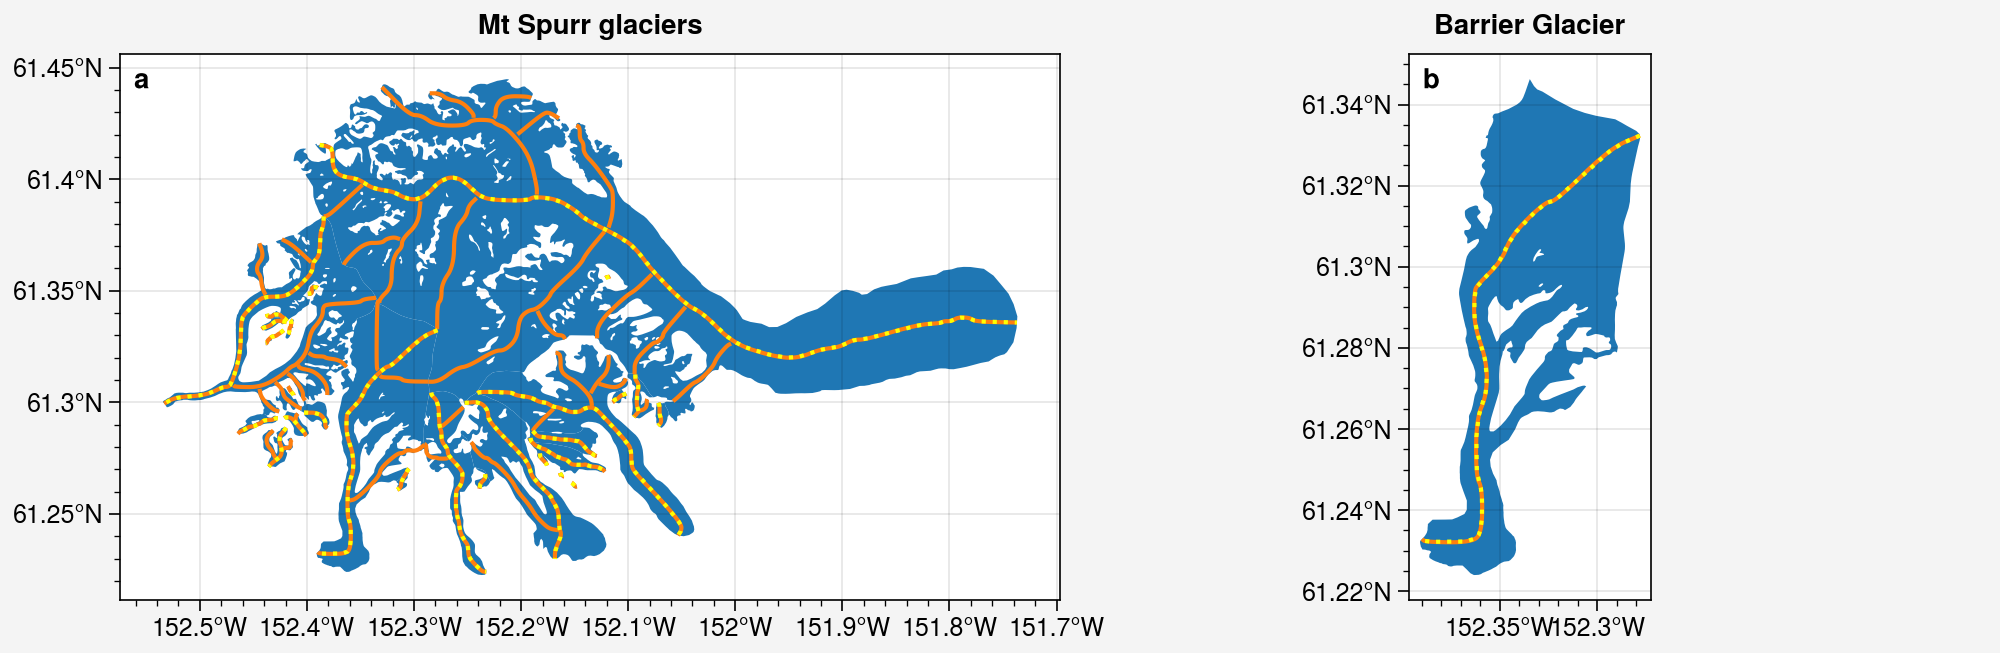

In [10]:
# Plot the glaciers and centre lines.
fig1, axs1 = uplt.subplots(ncols=2, nrows=1, share=0, figwidth=10)
axs1.format(toplabels=["Mt Spurr glaciers", "Barrier Glacier"], xformatter="deglon", yformatter="deglat", abc=True, abcloc="ul")

glaciers.plot(ax=axs1[0], color="tab:blue")
centrelines.plot(ax=axs1[0], color="tab:orange")
scl.loc[scl["is_main"] == 1].plot(ax=axs1[0], color="yellow", linestyle=":")

rgi_g.plot(ax=axs1[1], color="tab:blue")
rgi_cl.plot(ax=axs1[1], color="tab:orange")
rgi_sl.plot(ax=axs1[1], color="yellow", linestyle=":")

**Fig. 1** (**a**) The glaciers (blue), centre lines (orange), and downsampled main centre lines (yellow dotted) around Mount Spurr, Alaska, and (**b**) zoomed in view of Barrier Glacier.

## Download ITS_LIVE data

Retrieve [ITS_LIVE](https://its-live.jpl.nasa.gov/) glacier velocity data ([Gardner et al, 2025](https://doi.org/10.5194/tc-19-3517-2025)) for the vertices of the downsampled centre line.

In [11]:
data = itslive.velocity_cubes.get_time_series(
    rgi_sl.get_coordinates().values,
    variables=["v", "acquisition_date_img1", "acquisition_date_img2", "date_dt"]
)

In [12]:
# Setup the time dimension for plotting, based on the full range of the ITS_LIVE data and the chosen range.
tlimfull = (
    np.datetime64(np.array([d["time_series"].acquisition_date_img1.values.min() for d in data]).min(), "D"),
    np.datetime64(np.array([d["time_series"].acquisition_date_img2.values.max() for d in data]).max(), "D")
)
tfull = np.arange(tlimfull[0], tlimfull[1])
tshort = np.arange(np.datetime64(tlim[0]), np.datetime64(tlim[1]))

In [13]:
def itslive_shortest_baseline(t, ts, max_baseline=90):
    v = np.empty(t.shape)
    v[:] = np.nan
    dt = np.timedelta64(max_baseline, "D")*np.ones(t.shape)

    ts = ts.where(ts.acquisition_date_img2 >= t.min(), drop=True)
    
    for j in range(len(ts.v)):
        if np.isnan(ts.v[j]):  # Skip NaN velocity values.
            continue
    
        inds = ((t >= np.datetime64(ts.acquisition_date_img1.values[j], "D")) & (t <= np.datetime64(ts.acquisition_date_img2.values[j], "D")))
        if not any(inds):
            continue
    
        inds[inds] = (dt[inds] > np.timedelta64(ts.date_dt.values[j], "D"))
    
        v[inds] = ts.v[j]
        dt[inds] = np.timedelta64(ts.date_dt.values[j])

    return v, dt

### Visualise the glacier velocity time series for a single point

Extract the velocity time series for a single vertex approximately half way up the centre line of the glacier.

In [14]:
ps = data[int(len(data)/2)]["time_series"]

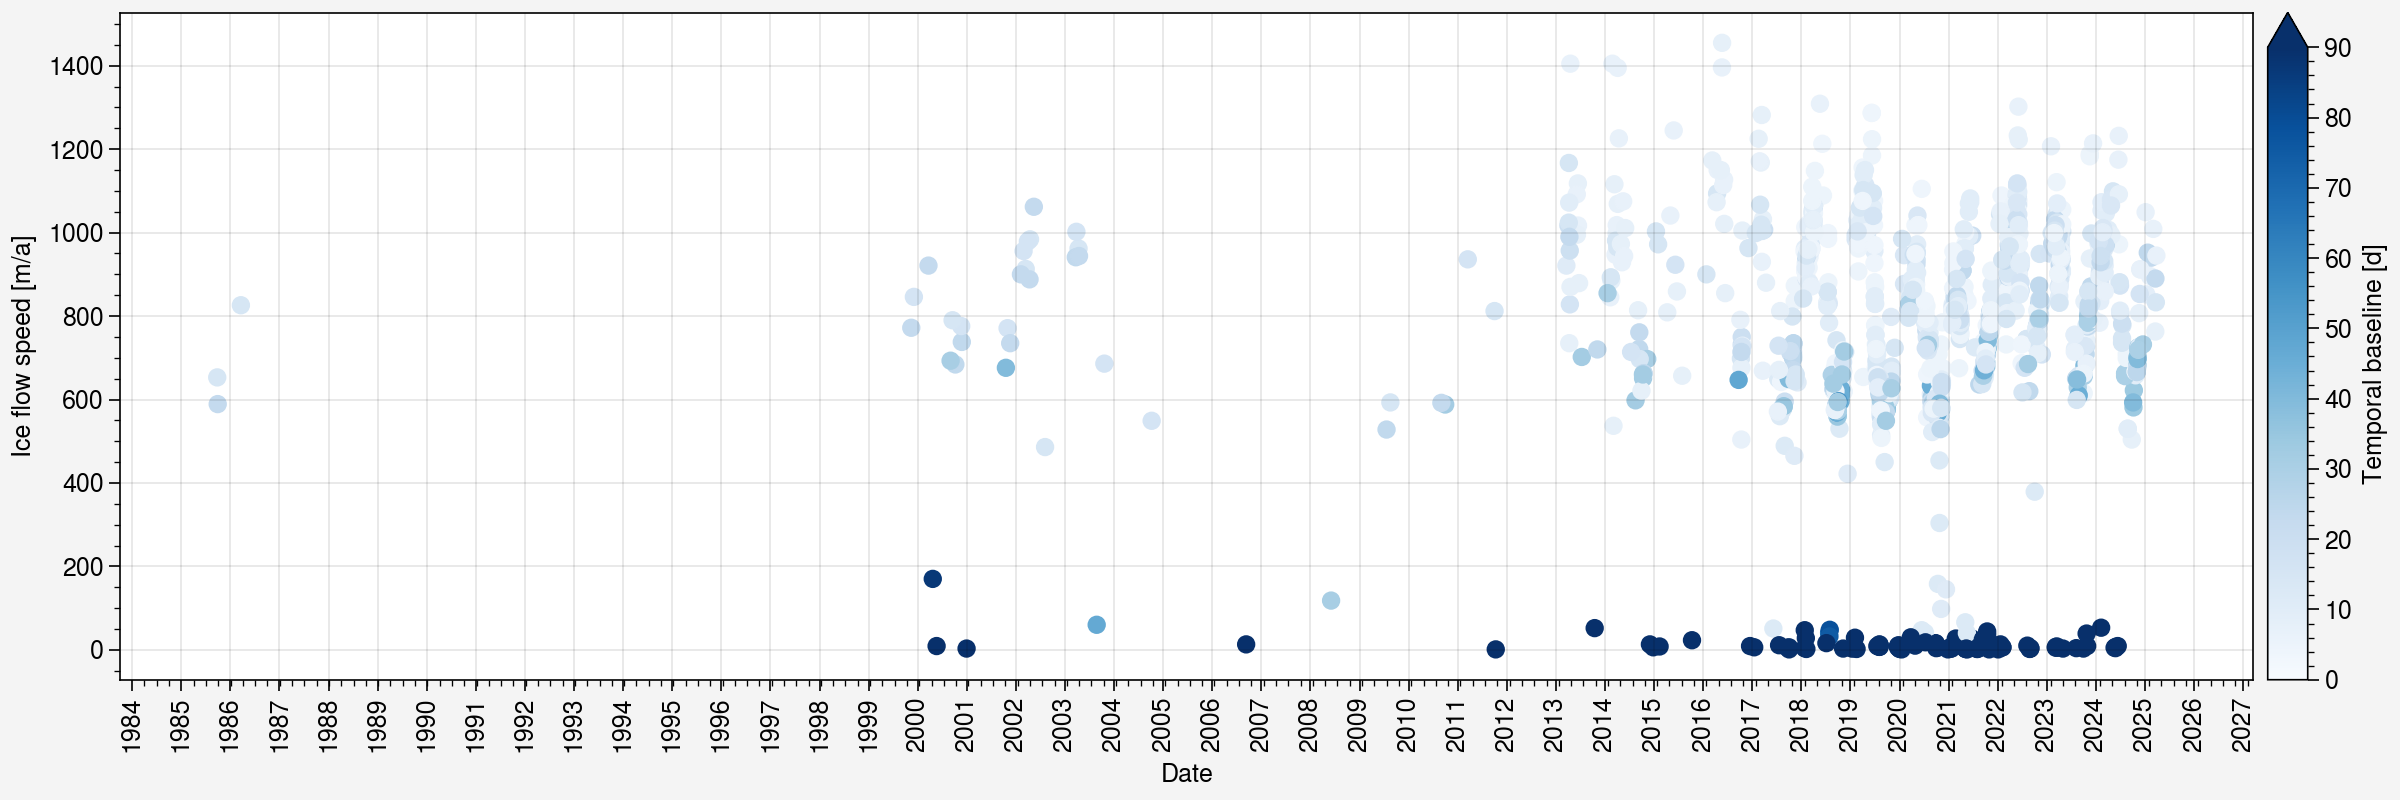

In [78]:
fig2, ax2 = uplt.subplots(ncols=1, nrows=1, share=0, figwidth=12, figheight=4)
ax2.format(xlocator="year", xlabel="Date", ylabel="Ice flow speed [m/a]")
m = ax2.scatter(ps.v, c=(ps["acquisition_date_img2"] - ps["acquisition_date_img1"]).dt.days.values, cmap="Blues", vmin=0, vmax=90)
ax2.colorbar(m, loc="r", extend="max", label="Temporal baseline [d]")

**Fig. 2** The raw ITS_LIVE velocity time series from a single point. The colour bar indicates the temporal baseline, i.e. the time separation, between the two satellite products used to compute the velocity measurements.  It is also evident how sparse the measurements are prior to measurements based on Landsat 8 starting in 2013 and then the Sentinel-1 and -2 in ~2016/17.

In [16]:
v, dt = itslive_shortest_baseline(t=tfull, ts=ps)

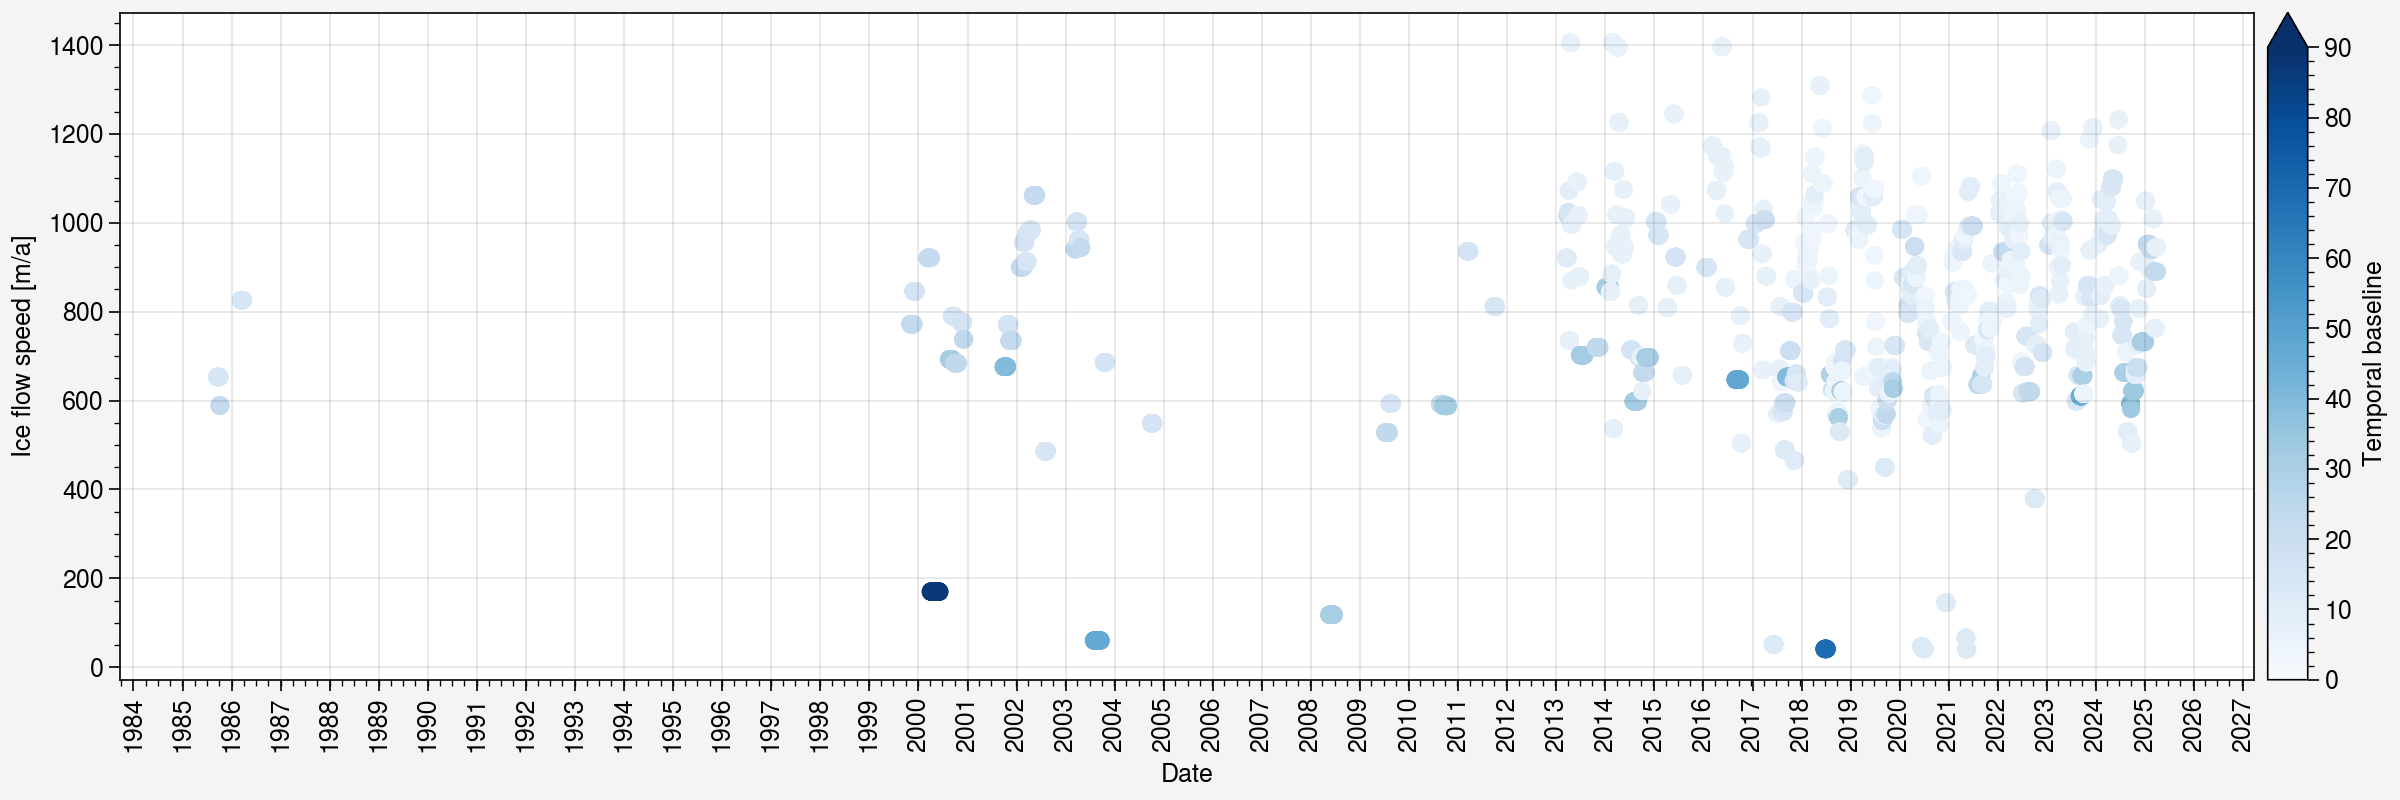

In [79]:
fig3, ax3 = uplt.subplots(ncols=1, nrows=1, share=0, figwidth=12, figheight=4)
ax3.format(xlocator="year", xlabel="Date", ylabel="Ice flow speed [m/a]")
m = ax3.scatter(tfull, v, c=dt, cmap="Blues", vmin=0, vmax=90)
ax3.colorbar(m, loc="r", extend="max", label="Temporal baseline")

**Fig. 3** The raw ITS_LIVE velocity time series from a single point, but only measurements with the shortest temporal baseline have been chosen. The colour bar indicates the temporal baseline, i.e. the time separation, between the two satellite products used to compute the velocity measurements.

Notice how the velocity measurements in **Fig. 3** have favoured the shorter baseline measurements from **Fig. 2**.

### Visualise the ITS_LIVE velocity time series for the whole centre line

First lets compute the distance between vertices along the glacier centre line.

In [18]:
pts = rgi_sl.to_crs(rgi_sl.estimate_utm_crs()).get_coordinates(ignore_index=True)
distance = np.zeros(len(pts))

for i in range(1, len(distance)):
    distance[i] = distance[i-1] + np.sqrt((pts.x[i] - pts.x[i-1])**2 + (pts.y[i] - pts.y[i-1])**2)

distance = distance.max() - distance  # Set the distance as zero at the terminus.

Create a 2D meshes for plotting the centre line velocity time series. We here use the shortened time span defined above to speed things along.

In [19]:
Xi, Ti = np.meshgrid(distance, tshort)
Vi = np.empty(Xi.shape)
Vi[:] = np.nan
dTi = np.copy(Vi)

Now we compile the velocity time series of all the vertices into the velocity mesh grid.

**!!! Attention !!!**

- Running this next step in Jupyter Notebook can be very slow.
  - My tests in Jupyter Notebook show up to ~30-90 seconds per iteration for each vertex.
- To speed things along, this code can be copied to other python IDEs or a script that is run in a command-line shell.

In [144]:
# This will take awhile ~30s per vertex.
for i in tqdm(range(len(data))):
    Vi[:, i], dTi[:, i] = itslive_shortest_baseline(t=tshort, ts=data[i]["time_series"])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 88/88 [1:25:36<00:00, 58.37s/it]


In [145]:
Vii = Vi.copy()

In [21]:
def plot_XTV(ax, X, T, V, **kwargs):
    df = pd.DataFrame({"x": X.flatten(), "t": T.flatten().astype("datetime64[ns]"), "v": V.flatten()})
    ds = df.set_index(["x", "t"]).to_xarray()

    xtv = ds["v"].plot.imshow(ax=ax, x="x", y="t", add_colorbar=False, add_labels=False, **kwargs)
    return xtv

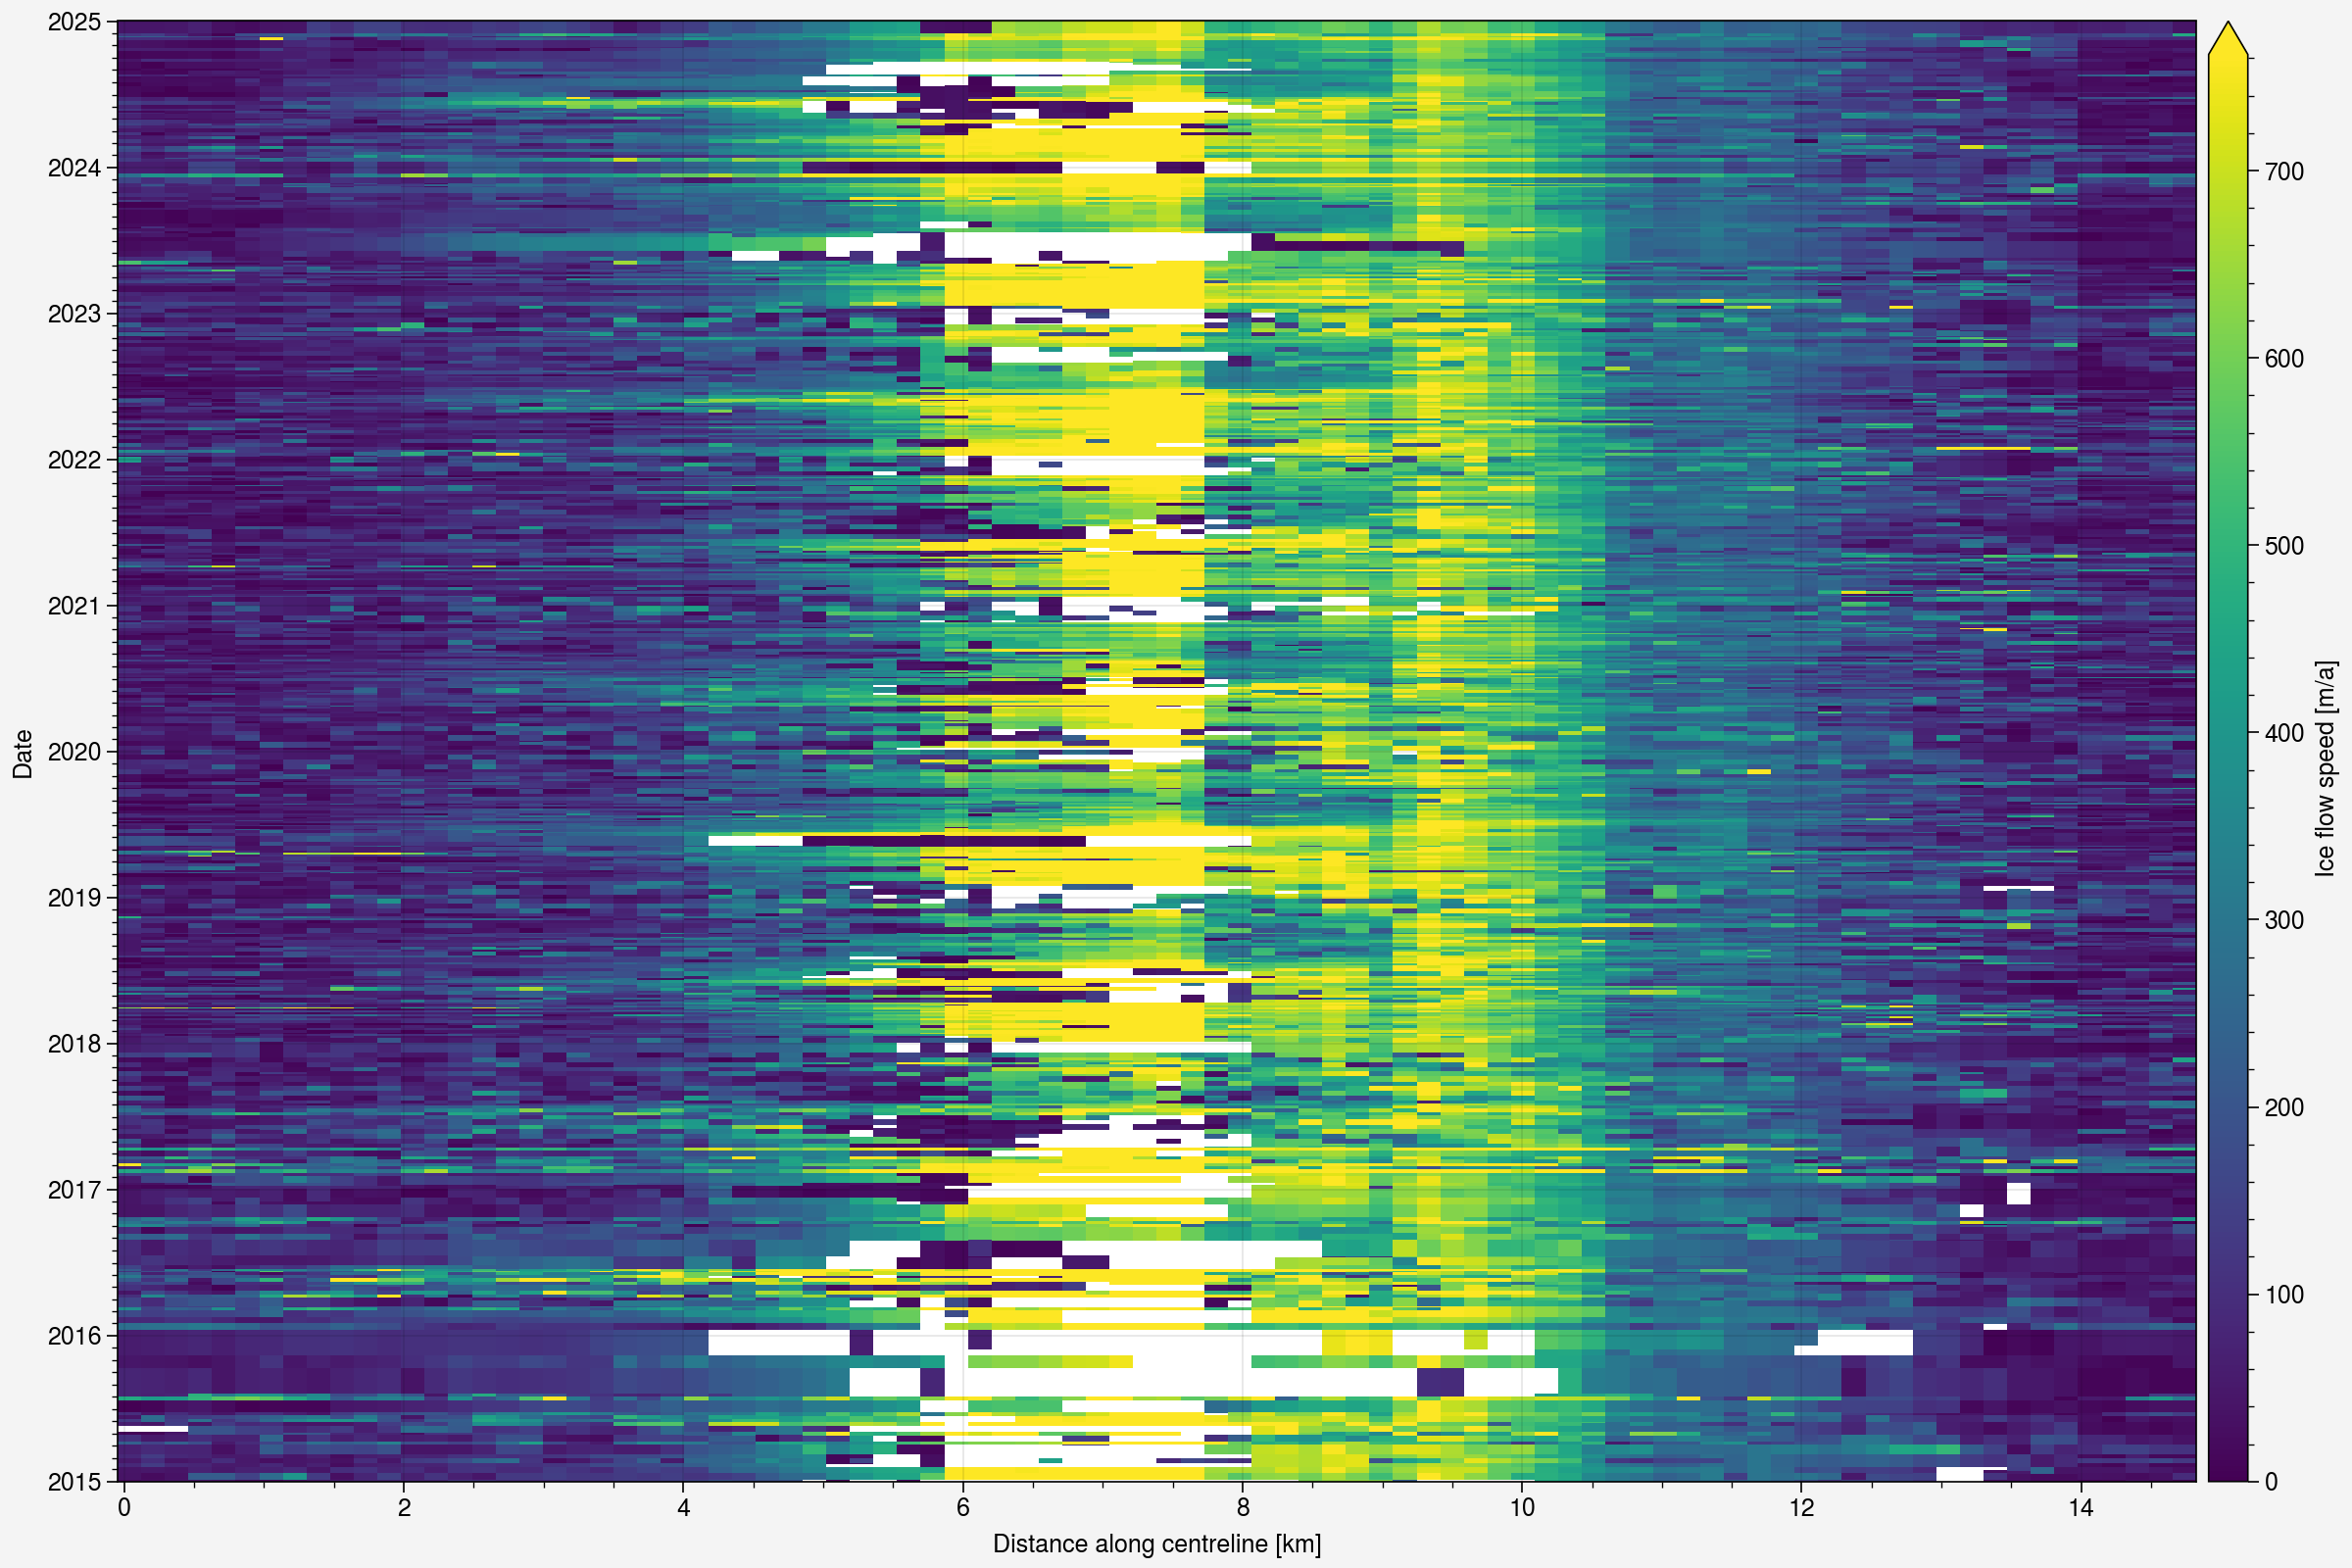

In [146]:
fig4, ax4 = uplt.subplots(ncols=1, nrows=1, share=0, figwidth=12, figheight=8)
ax4.format(ylocator="year", yminorlocator="month", ylabel="Date", ylim=(np.datetime64("2015-01-01"), np.datetime64("2025-01-01")), xlabel="Distance along centreline [km]")
xtv = plot_XTV(ax=ax4, X=Xi/1000, T=Ti, V=Vi, vmin=0, vmax=np.nanquantile(Vi, 0.95), cmap="viridis")
ax4.colorbar(xtv, loc="r", extend="max", label=r"Ice flow speed [m/a]")

**Fig. 4** ITS_LIVE velocity along the glacier centre line. The velocity is normalised to the maximum velocity with the colour range capped at the 95th quantile. Note that the glacier terminus is at 0 on the horizontal axis. The velocity for each vertex along the centre line are the same as in **Fig. 3**.

## Download TICOI data

Retrieve TICOI regularised ITS_LIVE glacier velocity data [(Charrier et al, 2025)](https://doi.org/10.5194/tc-19-4555-2025) for the vertices of the downsampled centre line.

The below function `ticoi_download_points` is based on the demo script "[How to process one pixel of ITS_LIVE data, stored on a cloud](https://github.com/ticoi/ticoi/blob/main/examples/basic/notebook/pixel_demo_its_live_on_cloud.ipynb)" from the [TICOI Github repository](https://github.com/ticoi/ticoi) of [(Charrier et al, 2025)](https://doi.org/10.5194/tc-19-4555-2025).

In [23]:
def ticoi_download_points(df_coords):
    if len(df_coords) == 1:
        show = True
    else:
        show = False

    DF_reg = pd.DataFrame()
    
    for i, lonlat in tqdm(enumerate(df_coords.values)):
        lon, lat = lonlat
        data_itslive, df_raw, df_reg = ticoi_one_pixel(
            cube_name=find_granule_by_point([lon, lat]), i=lon, j=lat, save=False,
            show=show, option_visual=["obs_magnitude", "invertvv", "inverpvv", "quality_metrics"],
            load_kwargs={"pick_date": tlim, "buffer": [lon, lat, 0.01], "chunks": {}},
            load_pixel_kwargs={"visual": True},
            preData_kwargs={"delete_outliers": {"median_angle": 45}},
            inversion_kwargs={"coef": 500, "result_quality": ["X_contribution"], "visual": show},
            interpolation_kwargs={"result_quality": ["X_contribution"]}
        )

        df_reg["longitude"] = lon
        df_reg["latitude"] = lat
        df_reg["distance"] = distance[(rgi_sl.get_coordinates(ignore_index=True).x == lon) & (rgi_sl.get_coordinates(ignore_index=True).y == lat)][0]
        
        if len(DF_reg) == 0:
            DF_reg = df_reg.copy()
        else:
            DF_reg = pd.concat([DF_reg, df_reg], ignore_index=True)

    DF_reg["date_cori"] = DF_reg.date1 + (DF_reg.date2 - DF_reg.date1) / 2
    # df["date_cori"] = df.date_cori.apply(pd.to_datetime, unit="D")
    DF_reg["date_cori"] = DF_reg.date_cori.dt.date
    DF_reg["temporal_baseline"] = (DF_reg.date2 - DF_reg.date1)
    DF_reg["offset_bar"] = (DF_reg.date2 - DF_reg.date1) / 2
    DF_reg["vv"] = np.sqrt(DF_reg.vx ** 2 + DF_reg.vy ** 2)
    
    return DF_reg

### Test TICOI for single point

Lets test and visualise the TICOI regularisation of ITS_LIVE velocity data for a point approximately half way up the glacier.

0it [00:00, ?it/s]

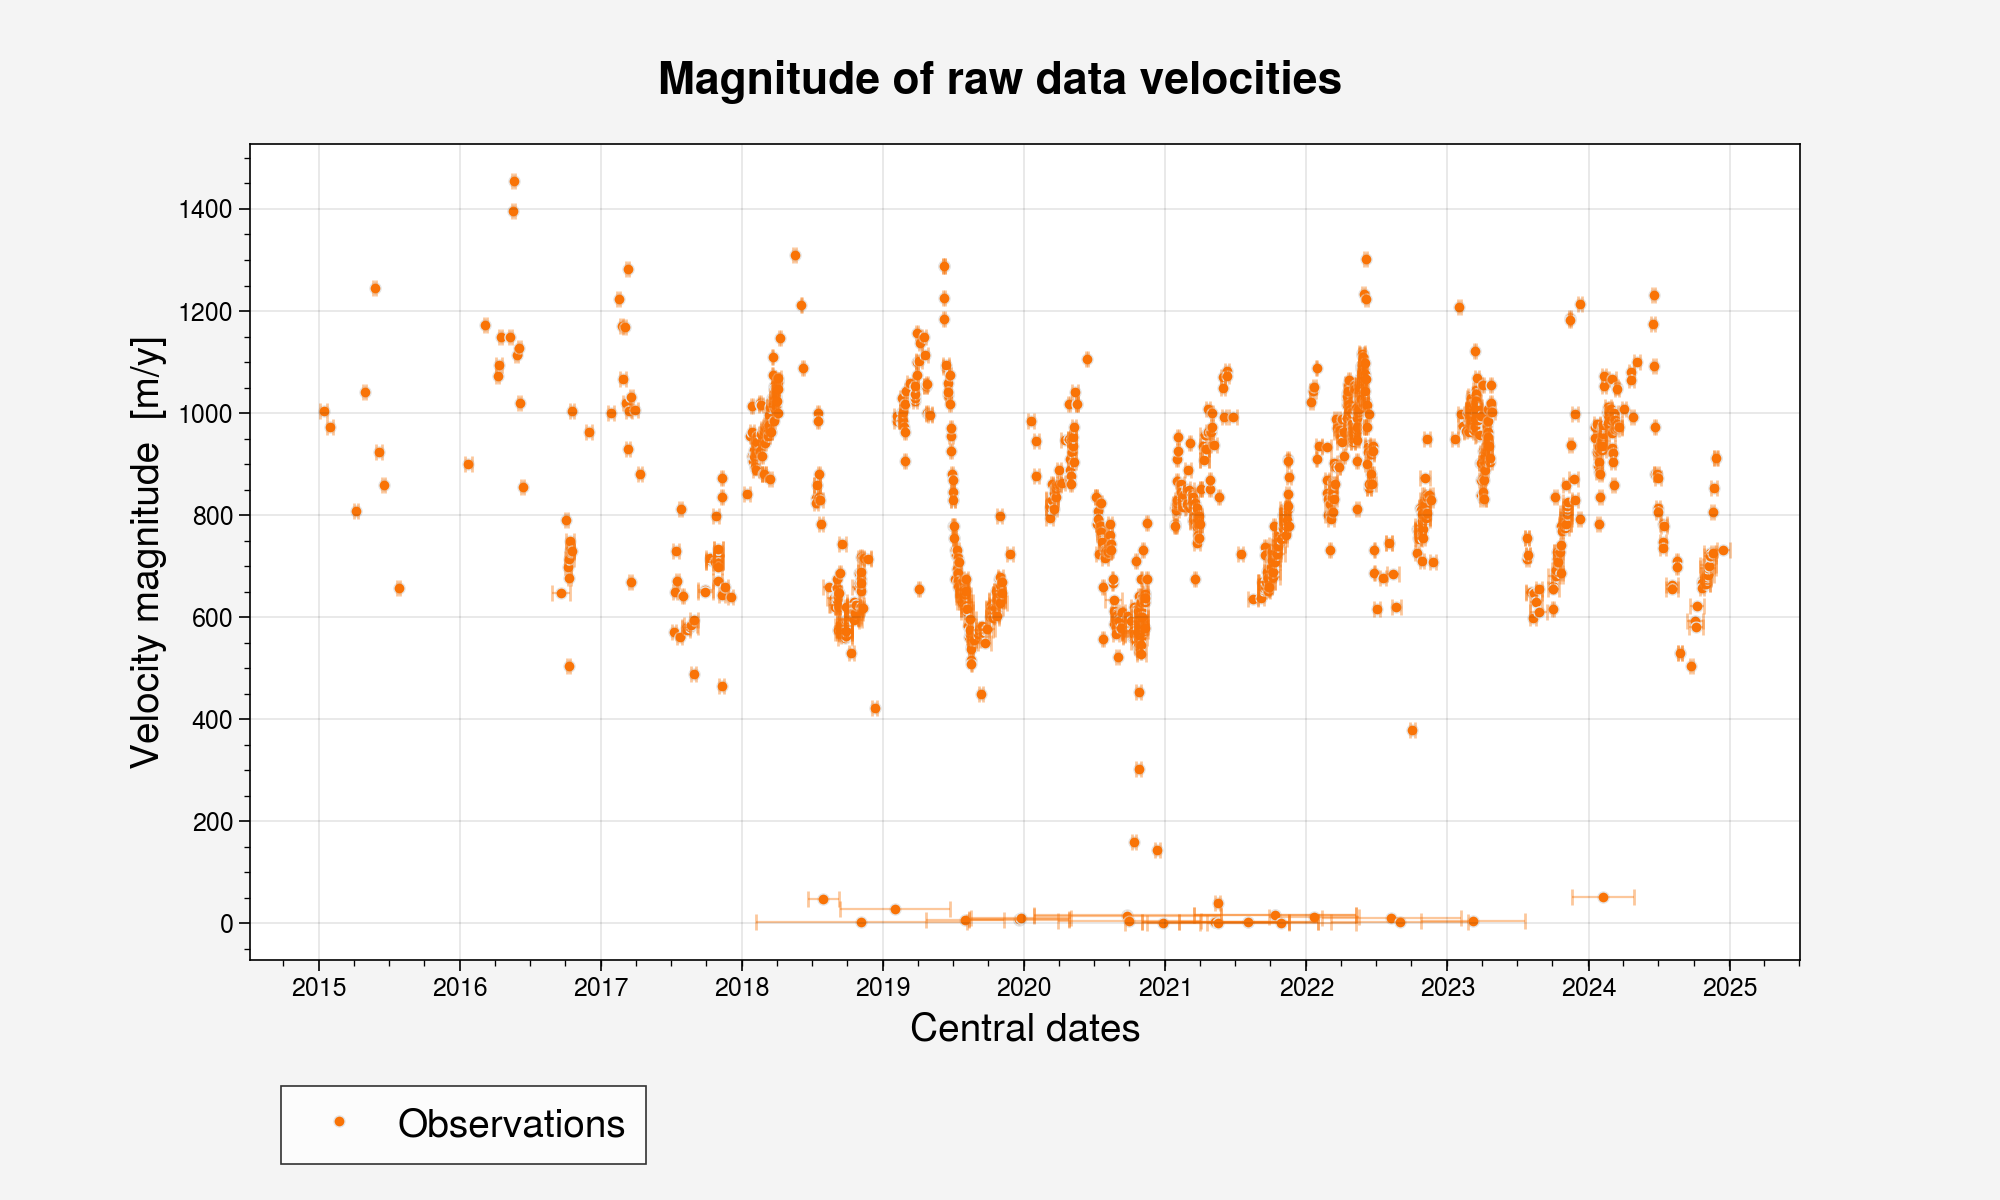

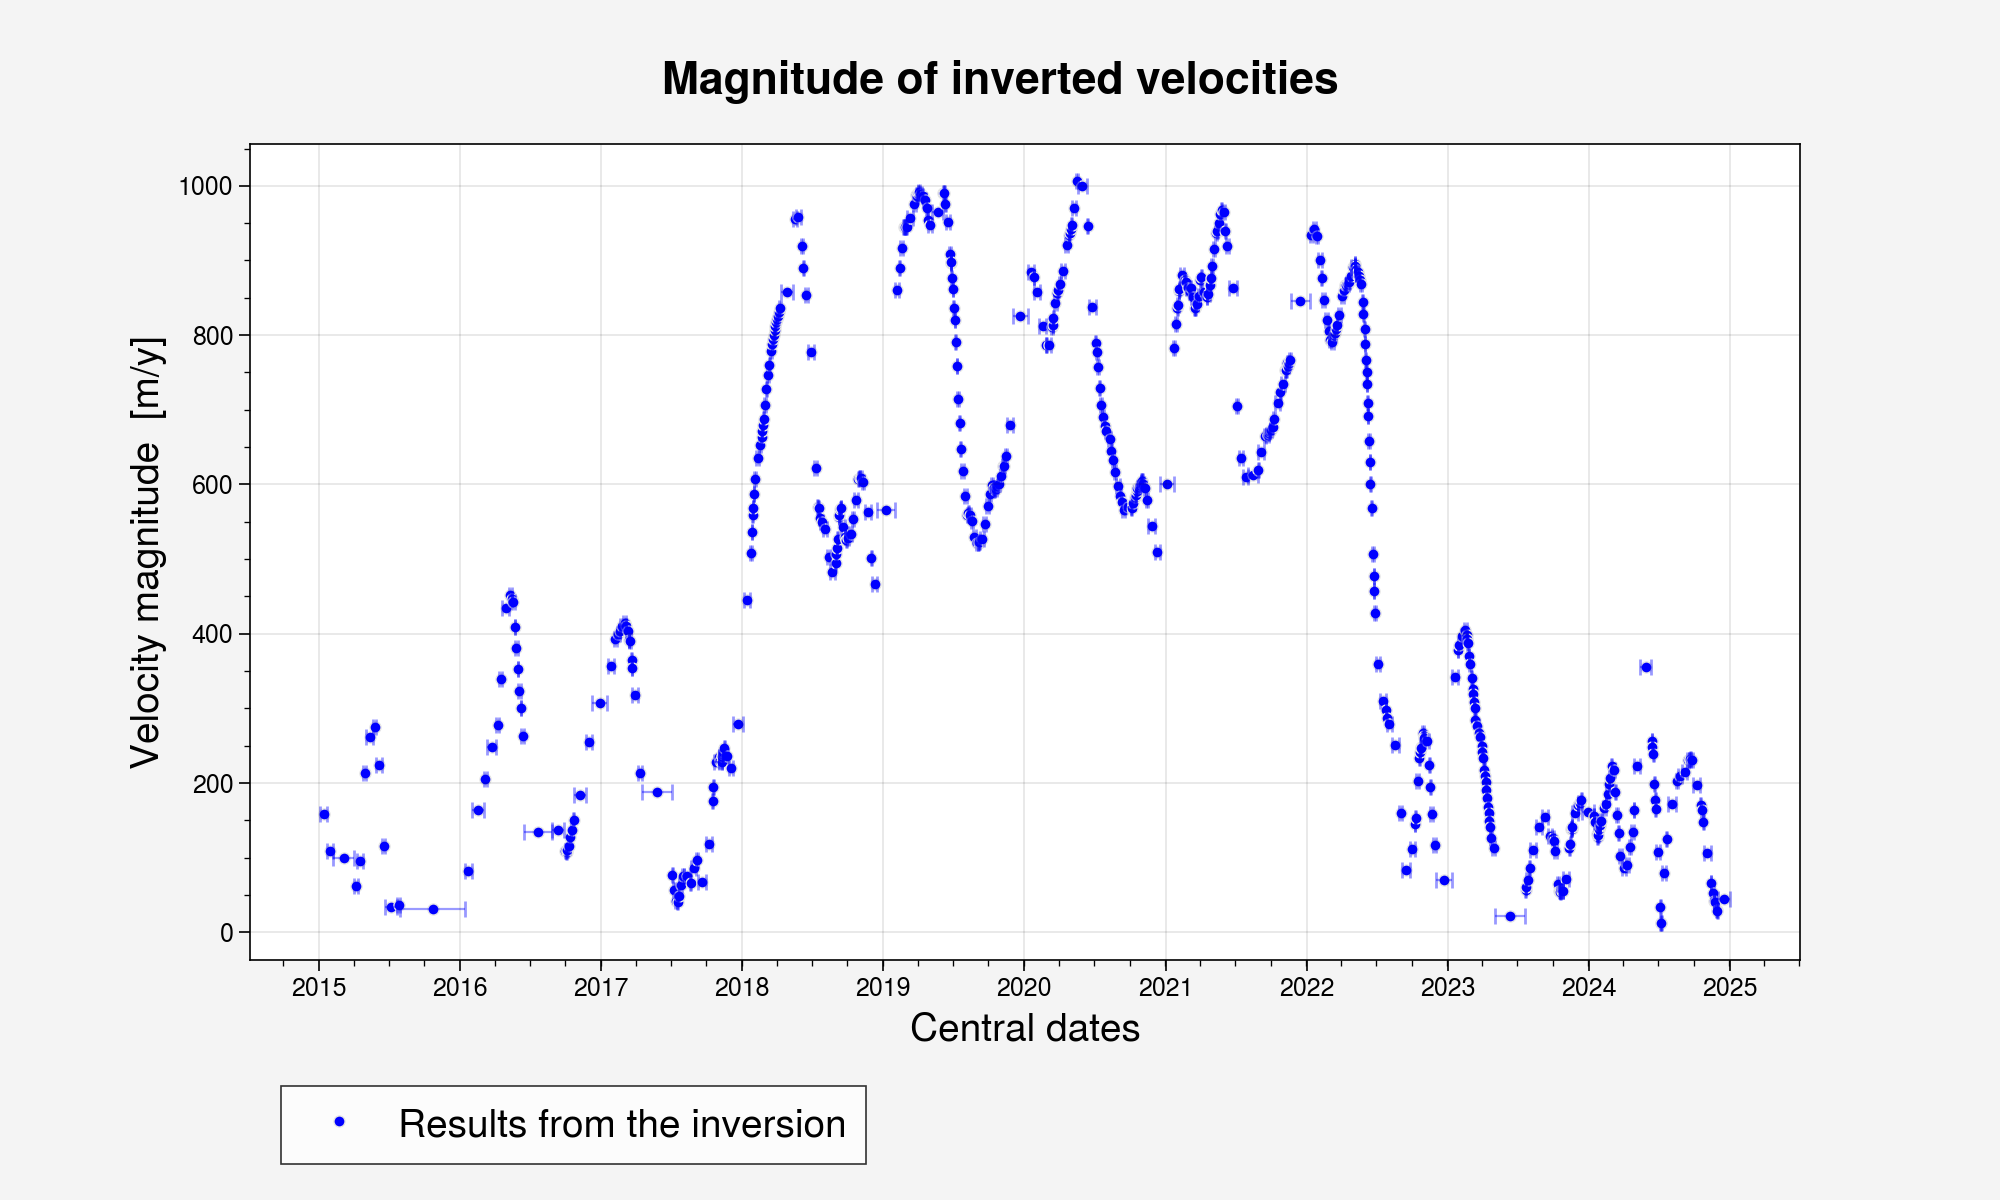

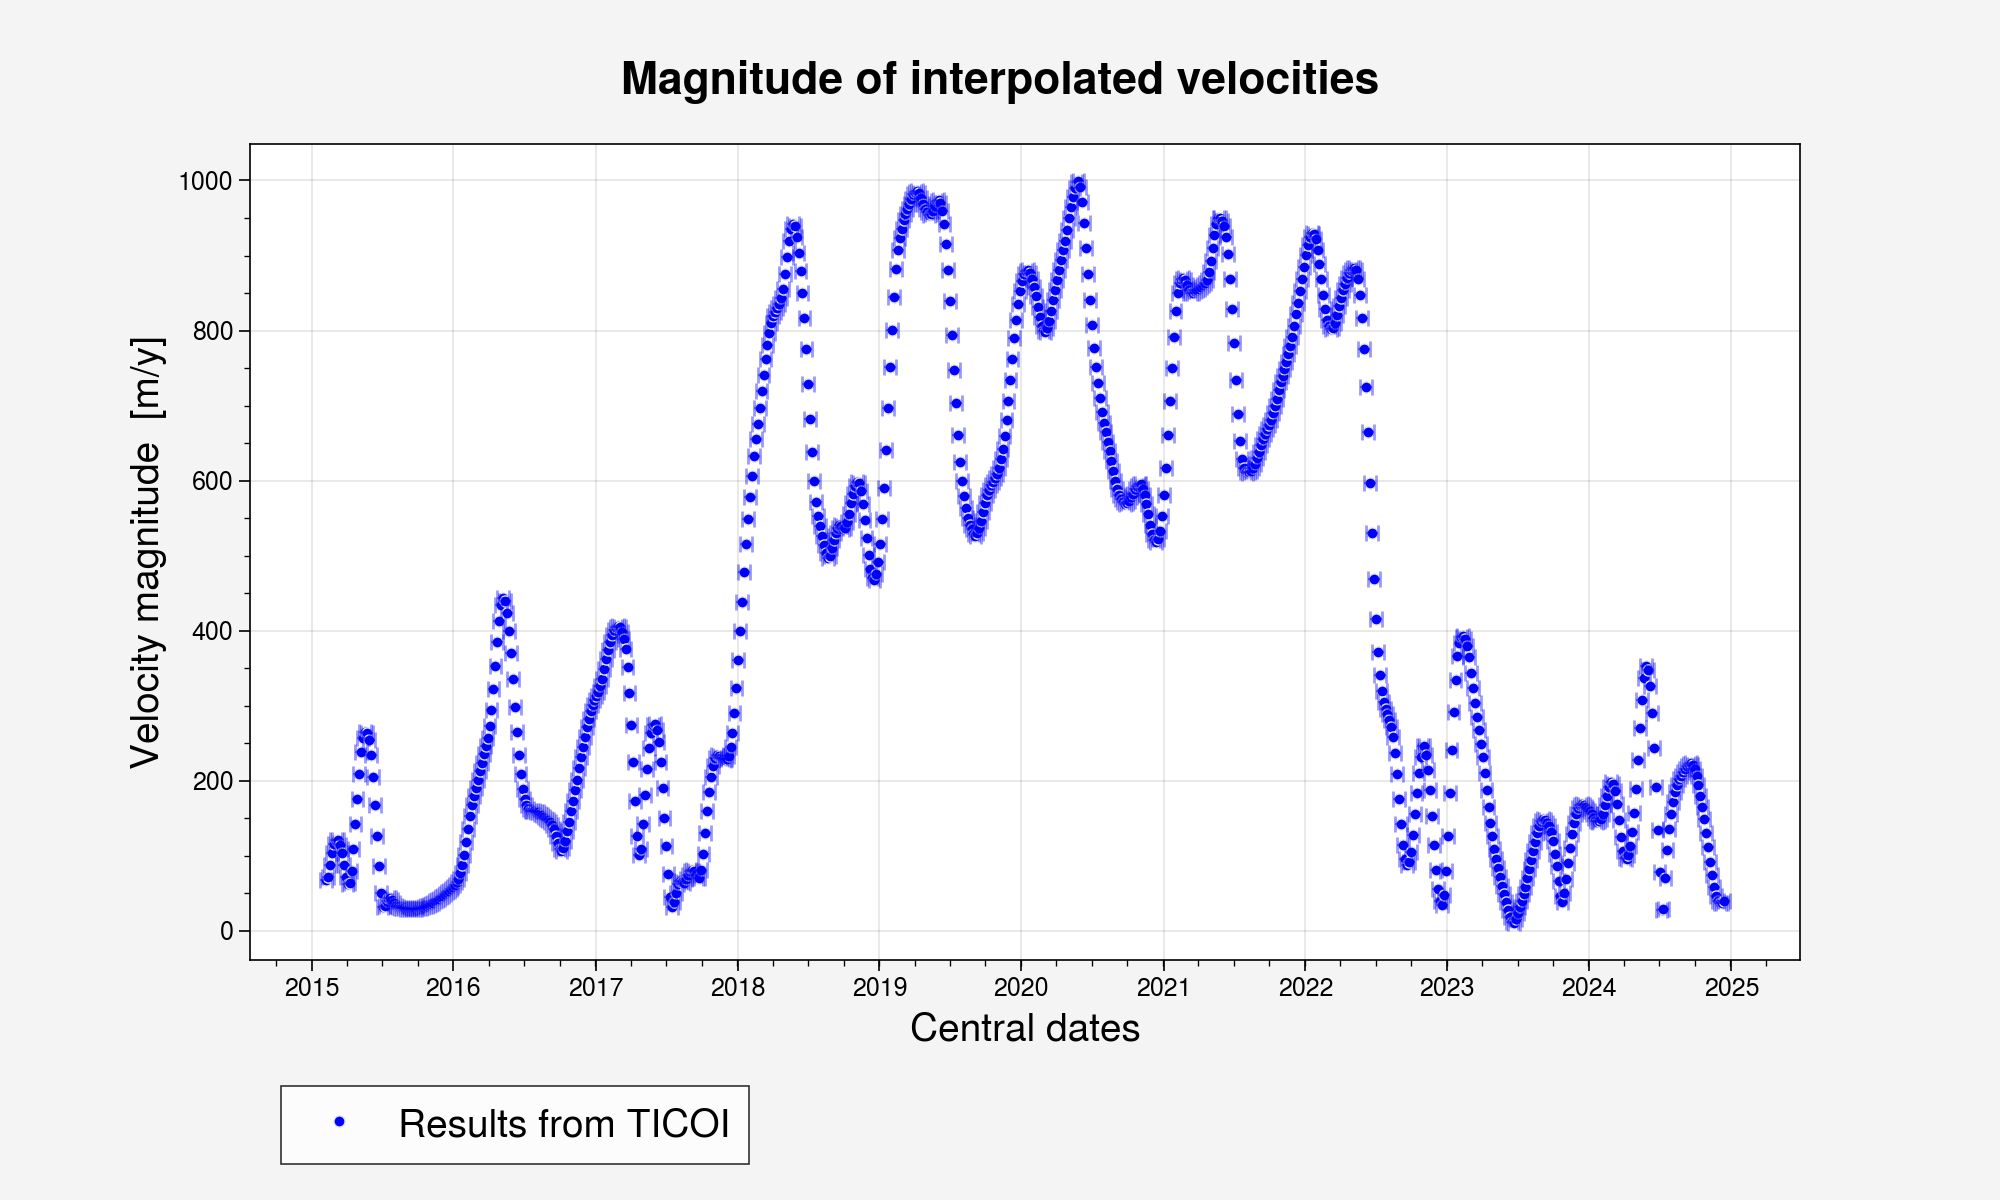

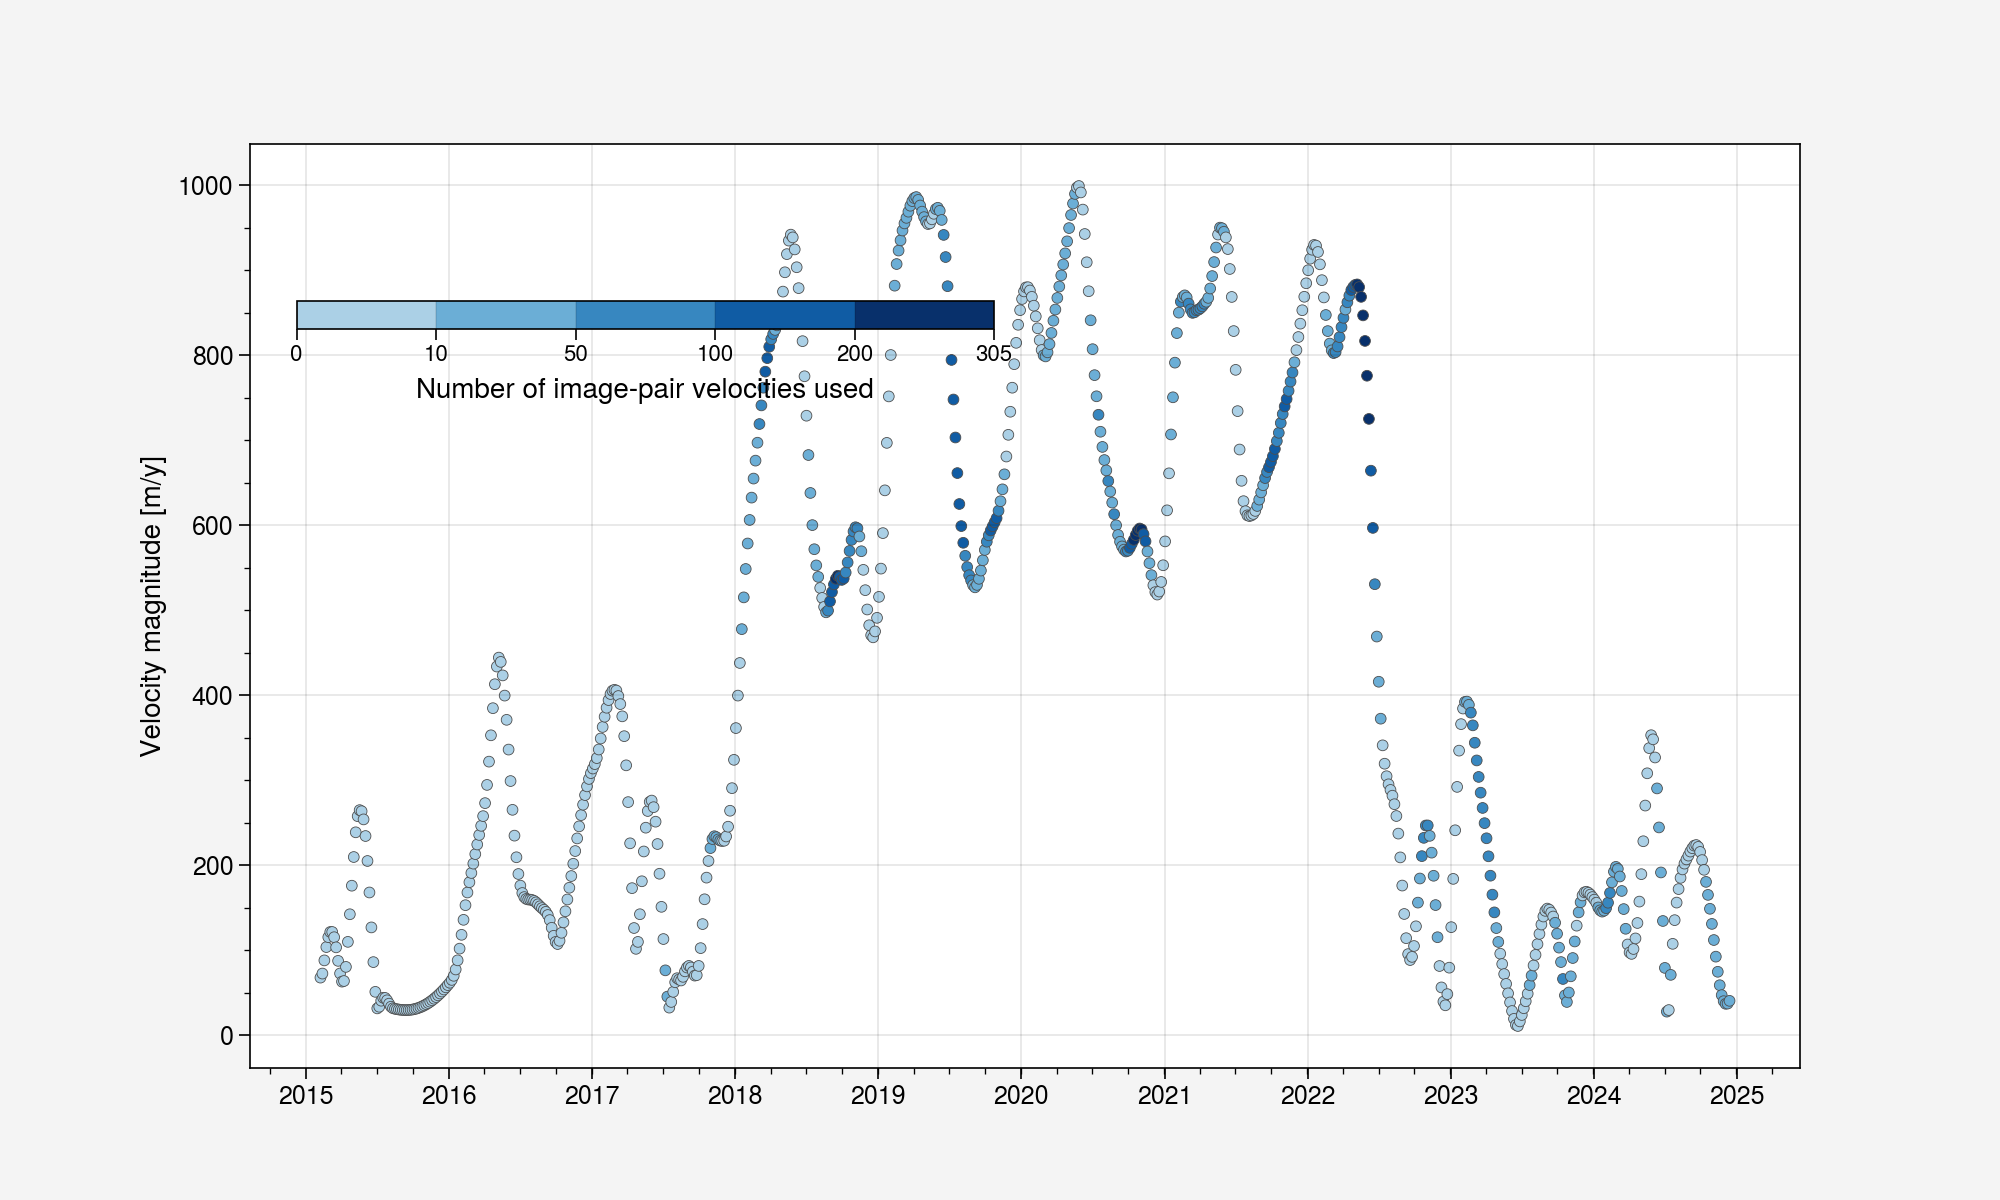

1it [01:52, 112.53s/it]


In [24]:
df = ticoi_download_points(df_coords=rgi_sl.get_coordinates().iloc[[int(len(distance)/2)]])

**Fig. 5** (**a**) Raw ITS_LIVE velocities. (**b**) TICOI inverted velocities. (**c**) TICOI regularised velocities. (**d**) Number of image-pair velocity measurements used to derive each regularised velocity data point.

### Visualise the TICOI velocity time series for the whole centre line

Just as we did for the raw ITS_LIVE velocities, we will compute the TICOI regularised velocities and display for the entire centre line of the glacier.

**!!! Attention !!!**

- Running the TICOI regularisation in Jupyter Notebook for the entire centre line can be very slow.
  - My tests in Jupyter Notebook show up to ~120 seconds per iteration for each vertex.
- To speed things along, this code can be copied to other python IDEs or a script that is run in a command-line shell.

In [25]:
df_t = ticoi_download_points(df_coords=rgi_sl.get_coordinates())

88it [2:50:02, 115.94s/it]


In [28]:
df_itslive = {"Xi": Xi.copy(), "Ti": Ti.copy(), "Vi": Vi.copy()}

In [27]:
df_ticoi = df_t.copy()

In [153]:
df_t = df_ticoi.copy()

In [154]:
Xt, Tt = np.meshgrid(df_t.distance.unique(), df_t.date_cori.unique())
Vt = np.empty(Xt.shape)
Vt[:] = np.nan
for i in range(Vt.shape[0]):
    for j in range(Vt.shape[1]):
        Vt[i, j] = df_t.vv.loc[(df_t.distance == Xt[i, j]) & (df_t.date_cori == Tt[i, j])].values[0]

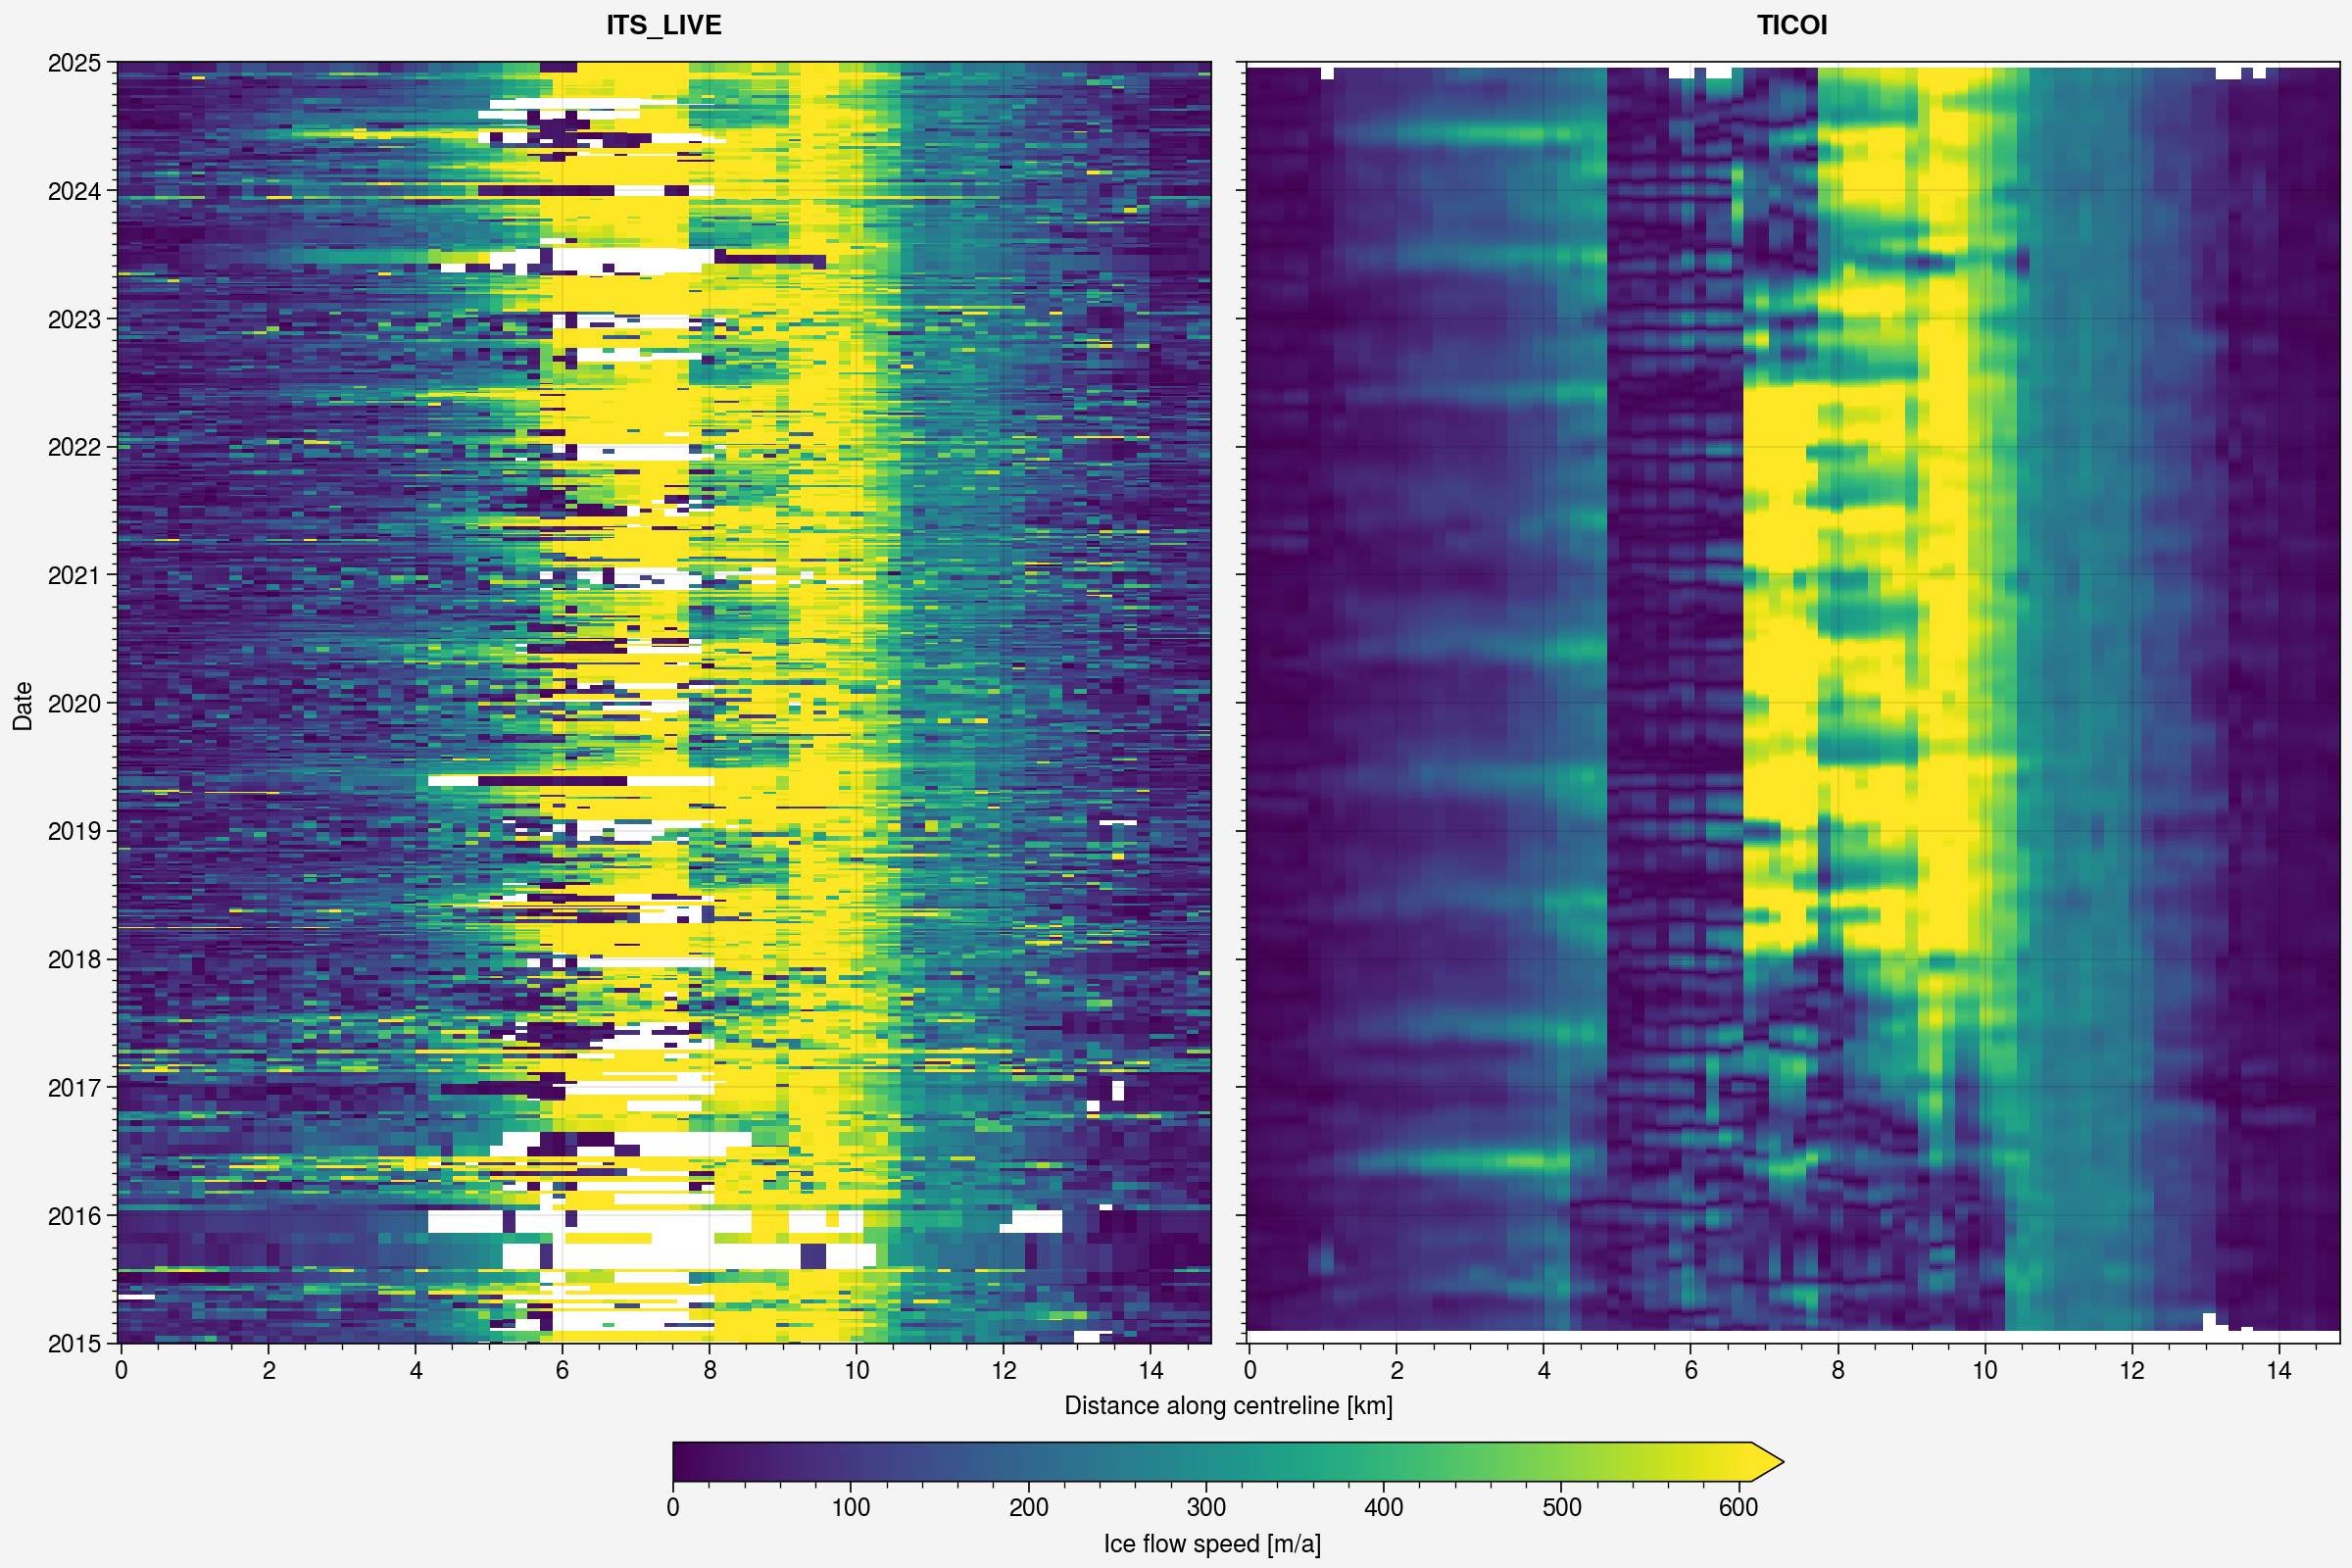

In [155]:
fig6, ax6 = uplt.subplots(ncols=2, nrows=1, share=True, figwidth=12, figheight=8)
ax6.format(ylocator="year", yminorlocator="month", ylabel="Date", ylim=(np.datetime64("2015-01-01"), np.datetime64("2025-01-01")), xlabel="Distance along centreline [km]", toplabels=["ITS_LIVE", "TICOI"])
xtvi = plot_XTV(ax=ax6[0], X=Xi/1000, T=Ti, V=Vi, vmin=0, vmax=np.nanquantile(Vt, 0.95), cmap="viridis")
xtvt = plot_XTV(ax=ax6[1], X=Xt/1000, T=Tt, V=Vt, vmin=0, vmax=np.nanquantile(Vt, 0.95), cmap="viridis")
fig6.colorbar(xtvt, loc="b", length=0.5, extend="max", label=r"Ice flow speed [m/a]")

**Fig. 6** (**a**) Raw and (**b**) TICOI regularised ITS_LIVE velocities along the glacier centre line. The velocity is normalised to the maximum velocity with the colour range capped at the 95th quantile. Note that the glacier terminus is at 0 on the horizontal axis. The velocity for each vertex along the centre line are the same as in **Fig. 5**.

Notice the surface locking/skipping between 5-7 km in the TICOI regularised time series for Barrier Glacier (**Fig. 5**).

## Comparison of ITS_live and TICOI time series deviation.

Lets compare the deviations from the mean, median and seasonal signal of the ITS_LIVE and TICOI velocity time series.

In [82]:
def norm_dev_from_median(V):
    V /= np.nanmax(V, axis=0)  #[:, None]
    V -= np.nanmedian(V, axis=0)  #[:, None]
    return V


def norm_dev_from_mean(V):
    V /= np.nanmax(V, axis=0)  #[:, None]
    V -= np.nanmean(V, axis=0)  #[:, None]
    return V


def norm_dev_from_seasonal(T, V):
    dV = np.empty(V.shape)
    dV[:] = np.nan

    for j in range(V.shape[1]):
        if np.isnan(V[:, j]).all():
            continue

        df = pd.DataFrame({"datetimeindex": T[:, j], "v": V[:, j]}).set_index("datetimeindex")
        inds = df.v.notna()
        df = df.loc[inds, :]
        try:
            result = seasonal_decompose(
                df, model="additive",
                period=int(365.25 / pd.to_timedelta((df.index[1:] - df.index[:-1]).unique().values[0]).days)
            )

            dV[inds, j] = df.v.values - result.seasonal.values
        except ValueError:
            continue

    return norm_dev_from_mean(V=dV)


def deviation(t, v, dev):
    if dev == "mean":
        v = norm_dev_from_mean(V=v)
    elif dev == "median":
        v = norm_dev_from_median(V=v)
    elif dev == "seasonal":
        v = norm_dev_from_seasonal(T=t, V=v)
    
    return v

### Deviation from the mean

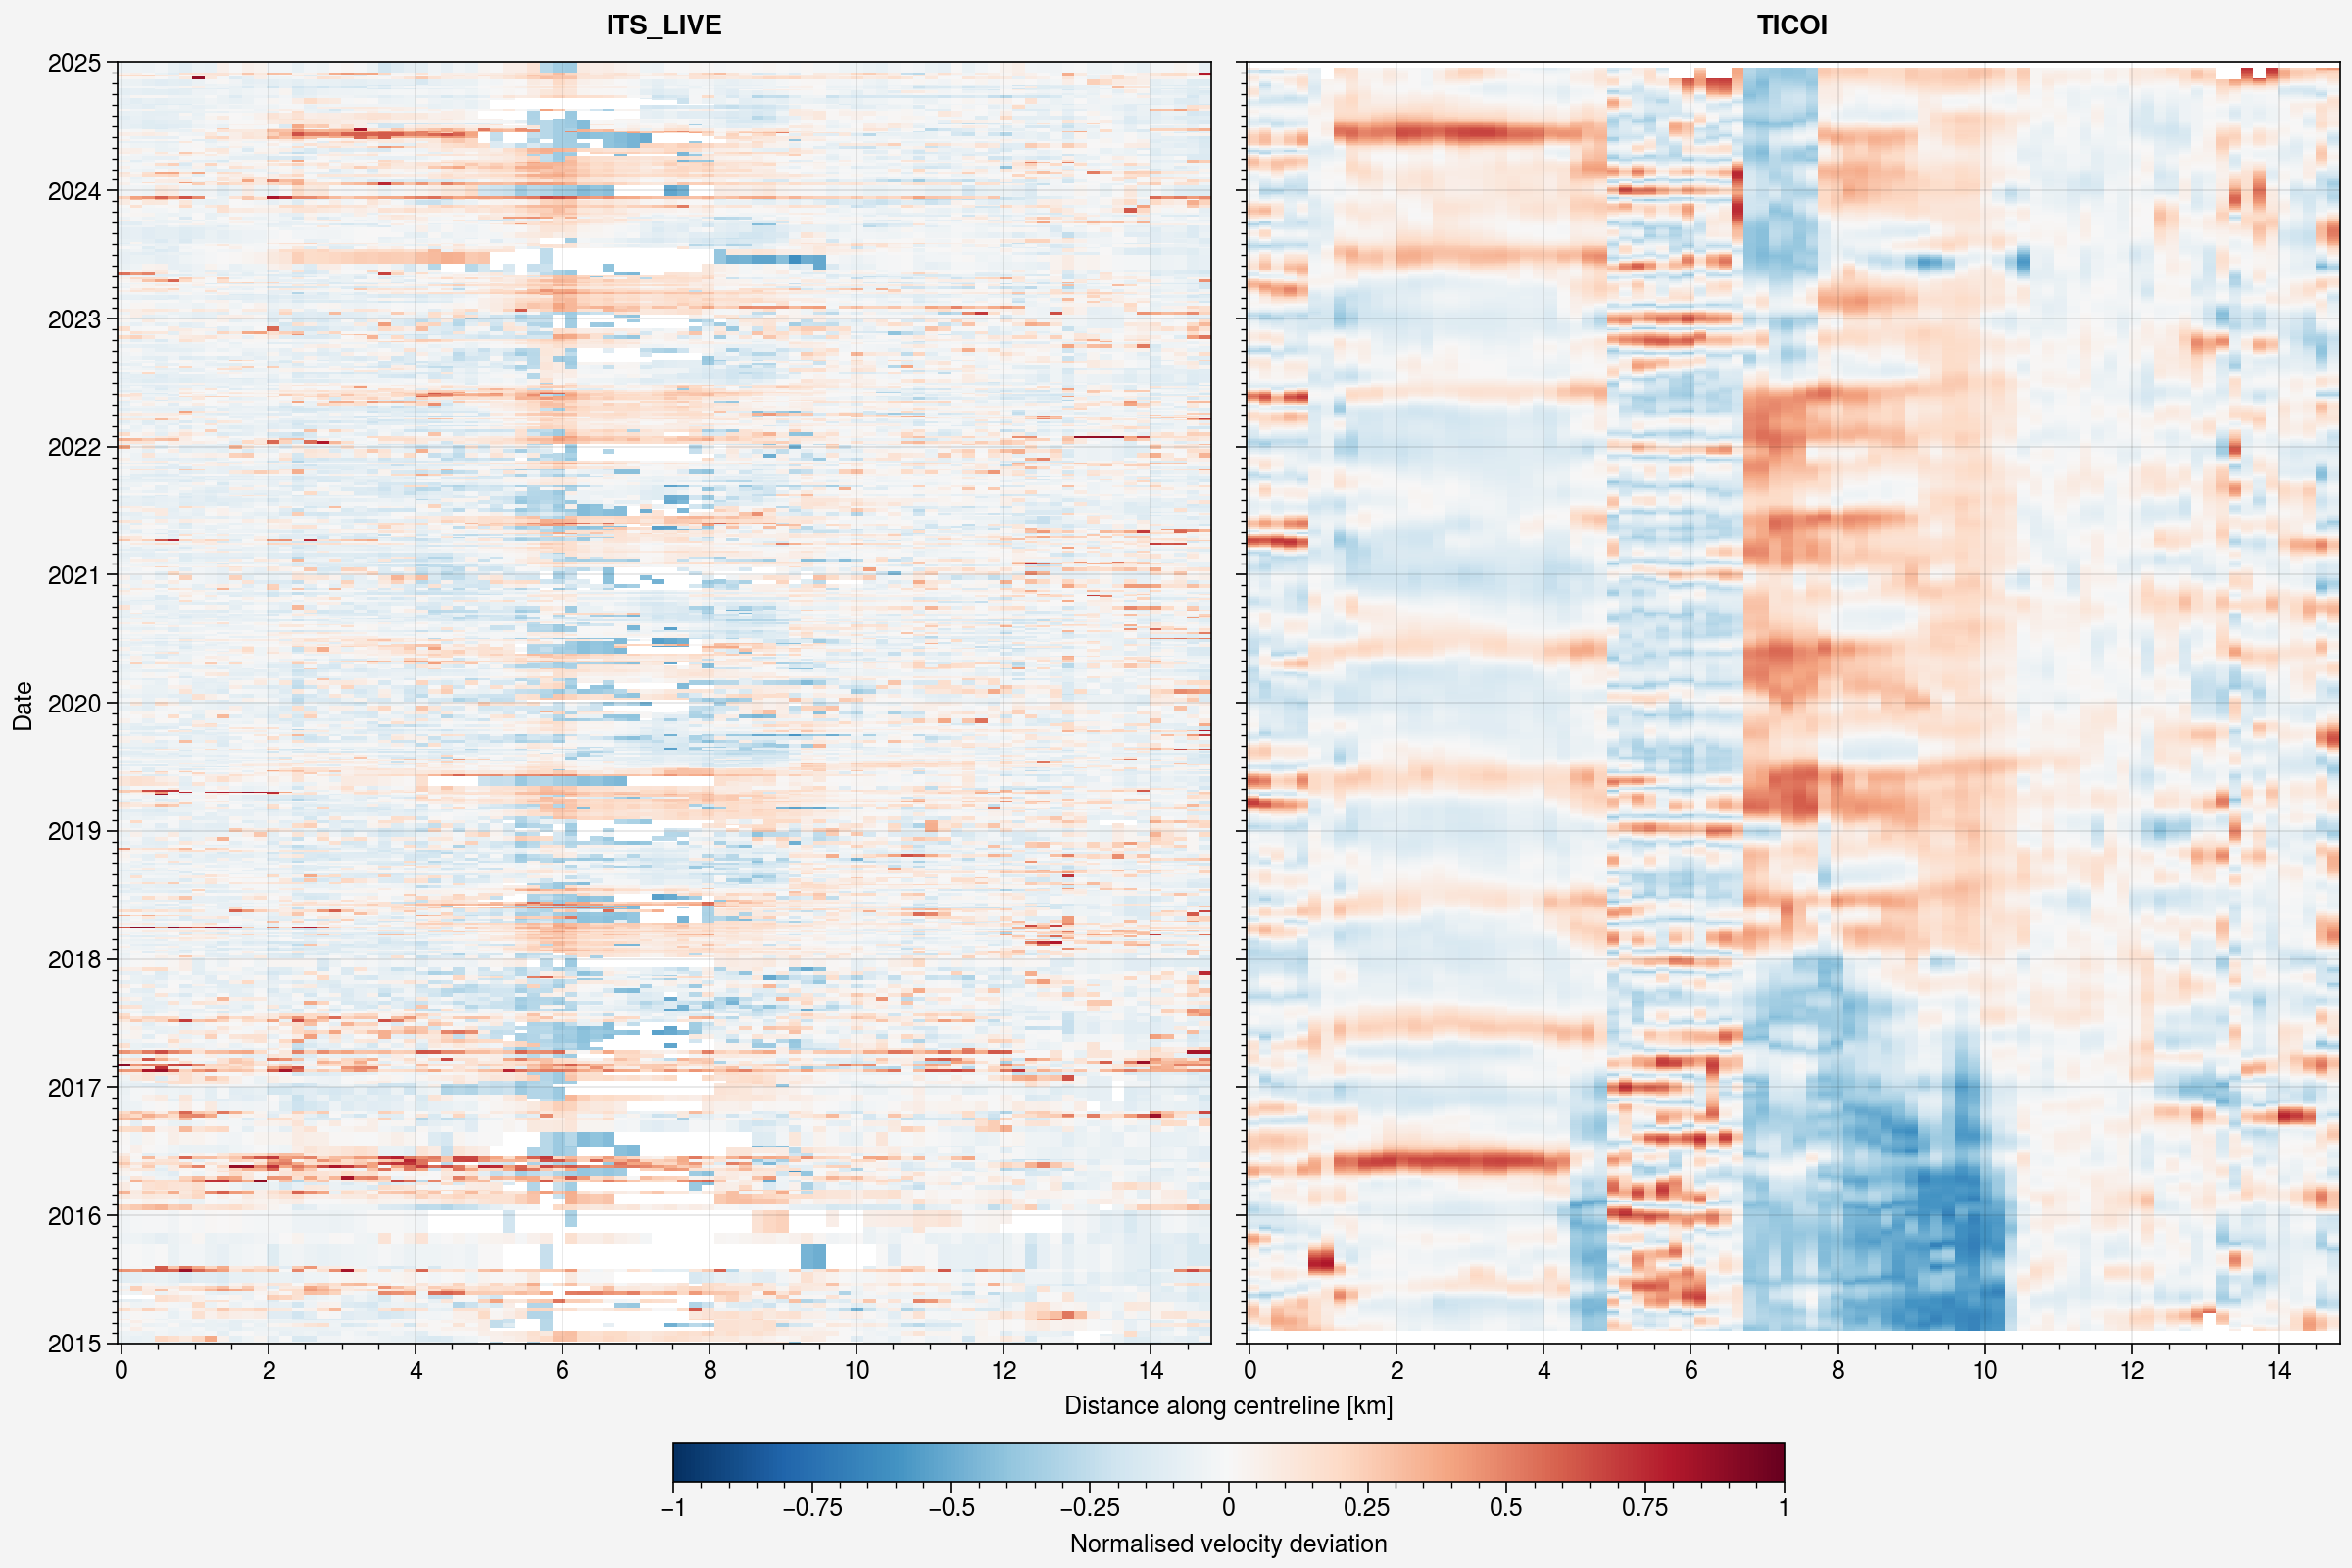

In [156]:
fig7, axs7 = uplt.subplots(ncols=2, nrows=1, share=True, figwidth=12, figheight=8)
axs7.format(ylocator="year", yminorlocator="month", ylabel="Date", ylim=(np.datetime64("2015-01-01"), np.datetime64("2025-01-01")), xlabel="Distance along centreline [km]", toplabels=["ITS_LIVE", "TICOI"])
xtvi = plot_XTV(ax=axs7[0], X=Xi/1000, T=Ti, V=deviation(t=Ti, v=Vi.copy(), dev="mean"), vmin=-1, vmax=1, cmap="RdBu_r")
xtvt = plot_XTV(ax=axs7[1], X=Xt/1000, T=Tt, V=deviation(t=Tt, v=Vt.copy(), dev="mean"), vmin=-1, vmax=1, cmap="RdBu_r")
fig7.colorbar(xtvt, loc="b", length=0.5, label="Normalised velocity deviation")

### Deviation from the median

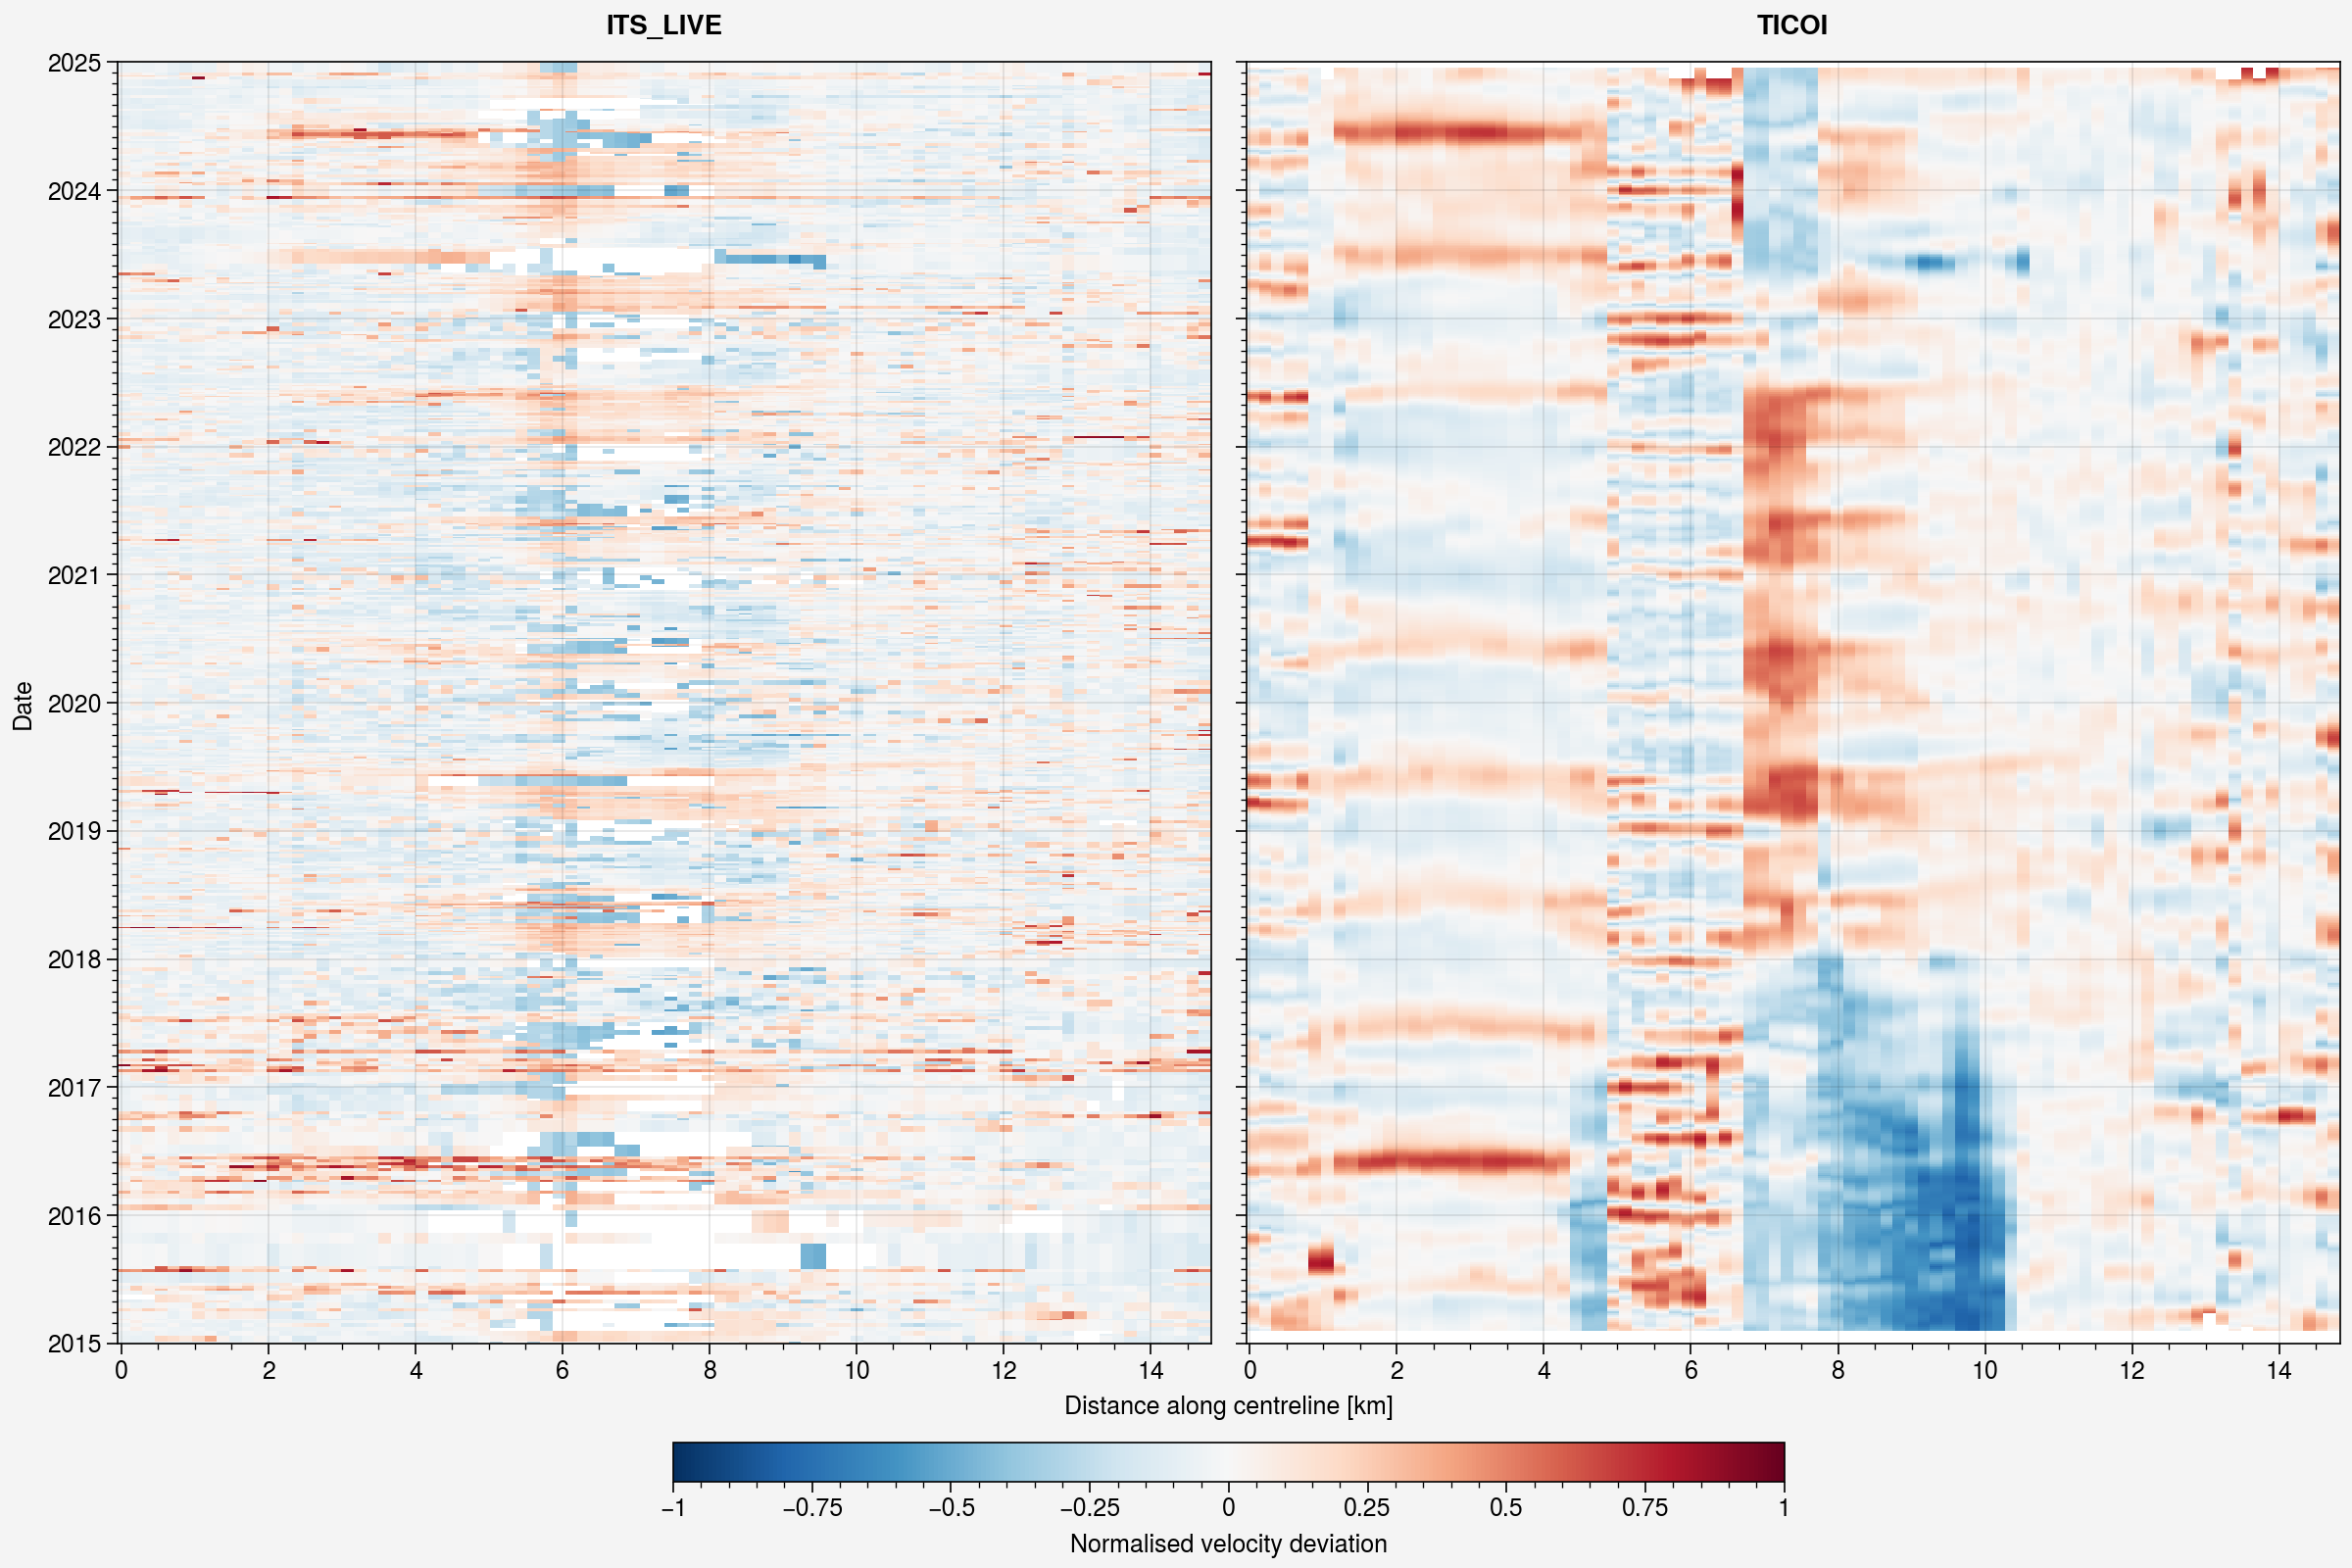

In [157]:
fig8, axs8 = uplt.subplots(ncols=2, nrows=1, share=True, figwidth=12, figheight=8)
axs8.format(ylocator="year", yminorlocator="month", ylabel="Date", ylim=(np.datetime64("2015-01-01"), np.datetime64("2025-01-01")), xlabel="Distance along centreline [km]", toplabels=["ITS_LIVE", "TICOI"])
xtvi = plot_XTV(ax=axs8[0], X=Xi/1000, T=Ti, V=deviation(t=Ti, v=Vi.copy(), dev="mean"), vmin=-1, vmax=1, cmap="RdBu_r")
xtvt = plot_XTV(ax=axs8[1], X=Xt/1000, T=Tt, V=deviation(t=Tt, v=Vt.copy(), dev="median"), vmin=-1, vmax=1, cmap="RdBu_r")
fig8.colorbar(xtvt, loc="b", length=0.5, label="Normalised velocity deviation")

### Deviation from seasonal velocity

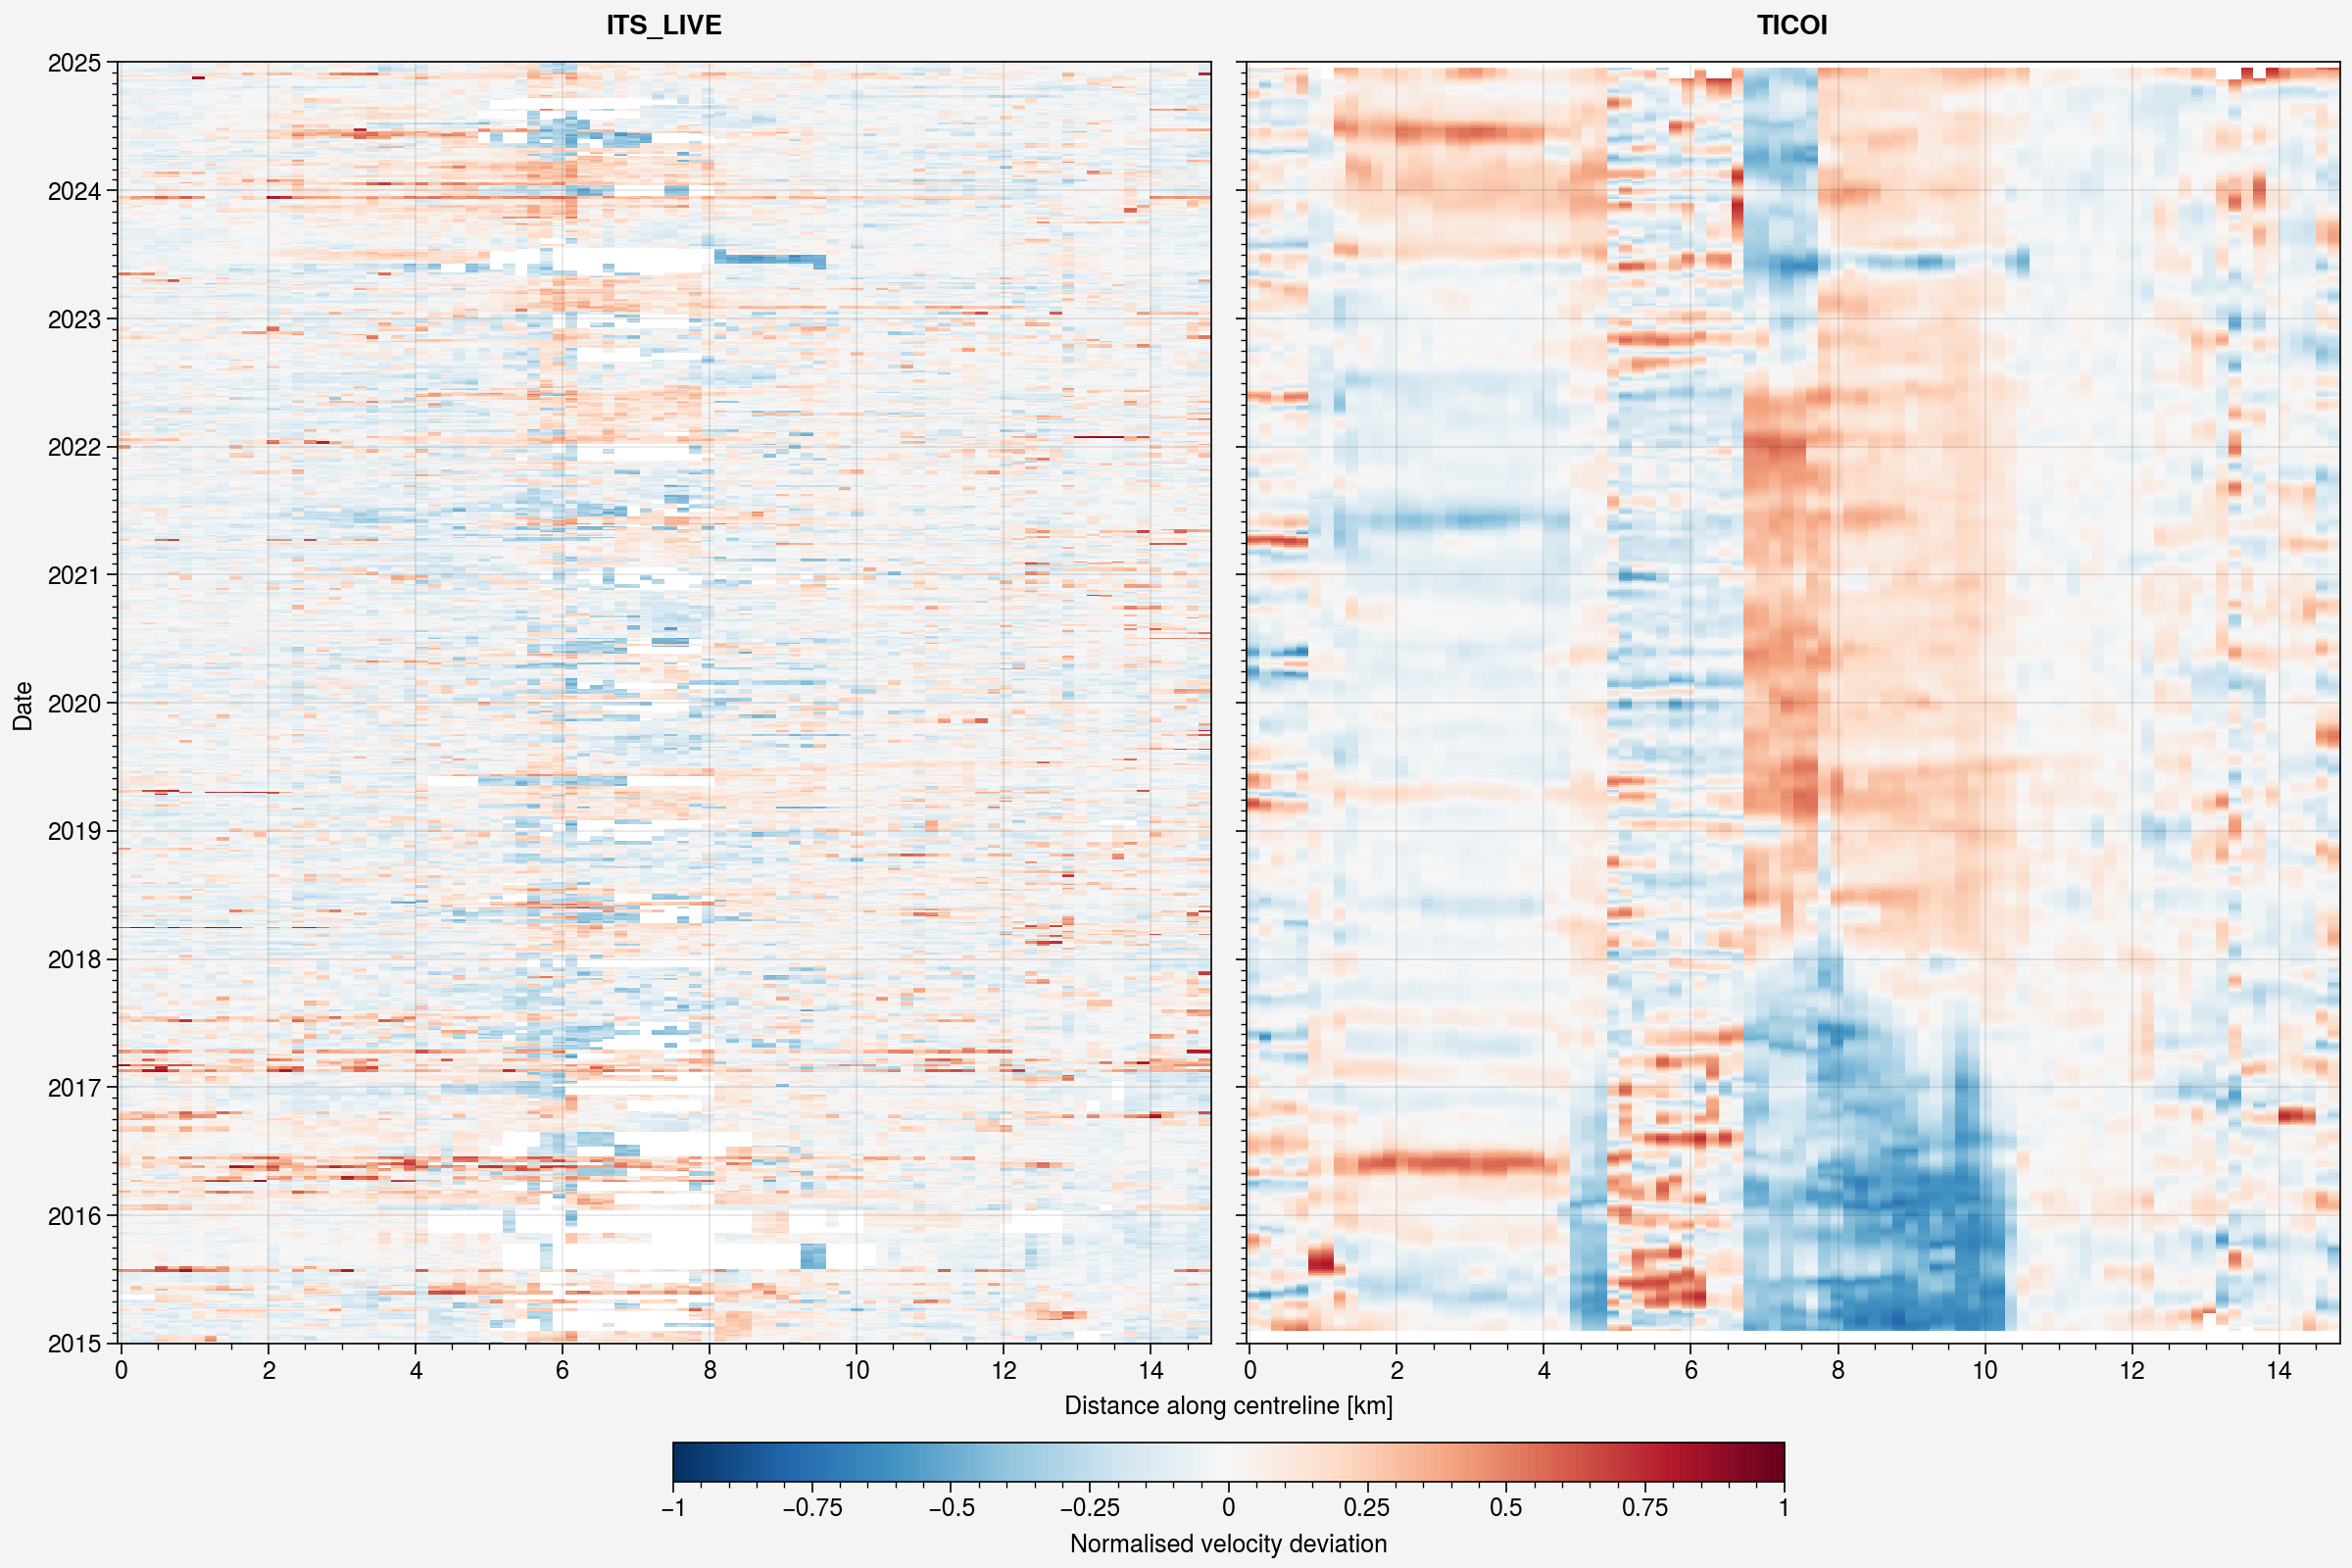

In [158]:
fig9, axs9 = uplt.subplots(ncols=2, nrows=1, share=True, figwidth=12, figheight=8)
axs9.format(ylocator="year", yminorlocator="month", ylabel="Date", ylim=(np.datetime64("2015-01-01"), np.datetime64("2025-01-01")), xlabel="Distance along centreline [km]", toplabels=["ITS_LIVE", "TICOI"])
xtvi = plot_XTV(ax=axs9[0], X=Xi/1000, T=Ti, V=deviation(t=Ti, v=Vi.copy(), dev="seasonal"), vmin=-1, vmax=1, cmap="RdBu_r")
xtvt = plot_XTV(ax=axs9[1], X=Xt/1000, T=Tt, V=deviation(t=Tt, v=Vt.copy(), dev="seasonal"), vmin=-1, vmax=1, cmap="RdBu_r")
fig9.colorbar(xtvt, loc="b", length=0.5, label="Normalised velocity deviation")